# Leica-style IRF reconstruction vs Machine IRF

Compare FLIMKit fitting with two IRF strategies against Leica LAS X ground truth:

1. **Machine IRF** — pre-measured `machine_irf_default.npy`, peak-aligned to decay
2. **Reconstructed IRF** — extract rising edge from decay (Leica's method: rising edge + hard BaP truncation)

Test data: `/Volumes/My Passport/2026_04_15_09_54_32--Test chems/`
- 9× Rh6G PTUs (3 frame settings × 3 resolutions)
- 9× EryB PTUs  (same)
- Each has a `_fit.xlsx` with Leica's 1-exp fit result

In [1]:
import sys, glob, os
import numpy as np
import pandas as pd
import openpyxl
from pathlib import Path

sys.path.insert(0, "/Users/as-hunt/FLIMKit")
from flimkit.PTU.reader import PTUFile
from flimkit.FLIM.irf_tools import (
    reconstruct_irf_from_decay,
    build_full_irf,
)
from flimkit.FLIM.fitters import fit_summed
from flimkit.FLIM.fit_tools import find_irf_peak_bin

DATA_DIR = Path("/Volumes/My Passport/2026_04_15_09_54_32--Test chems")
MACHINE_IRF = np.load("/Users/as-hunt/FLIMKit/flimkit/machine_irf/machine_irf_default.npy")

# Gather all PTU + _fit.xlsx pairs (exclude Combined and H2O)
pairs = []
for ptu_path in sorted(DATA_DIR.glob("*.ptu")):
    name = ptu_path.stem
    if name.startswith("Combined") or name.startswith("H2O"):
        continue
    fit_xlsx = DATA_DIR / f"{name}_fit.xlsx"
    if fit_xlsx.exists():
        dye = "Rh6G" if name.startswith("Rh6G") else "EryB"
        pairs.append({"ptu": ptu_path, "fit_xlsx": fit_xlsx, "dye": dye, "name": name})

print(f"Found {len(pairs)} PTU/fit_xlsx pairs:")
for p in pairs:
    print(f"  [{p['dye']}] {p['name']}")

Found 16 PTU/fit_xlsx pairs:
  [EryB] EryB_F2L2_512x512_ex455_HyDX2
  [EryB] EryB_F4L4_1024x1024_ex455_HyDX2
  [EryB] EryB_F4L4_2048x2048_ex455_HyDX2
  [EryB] EryB_F4L4_512x512_ex455_HyDX2
  [EryB] EryB_F8L8_1024x1024_ex455_HyDX2
  [EryB] EryB_F8L8_2048x2048_ex455_HyDX2
  [EryB] EryB_F8L8_512x512_ex455_HyDX2
  [Rh6G] Rh6G_F2L2_1024x1024_ex455_HyDX2
  [Rh6G] Rh6G_F2L2_2048x2048_ex455_HyDX2
  [Rh6G] Rh6G_F2L2_512x512_ex455_HyDX2
  [Rh6G] Rh6G_F4L4_1024x1024_ex455_HyDX2
  [Rh6G] Rh6G_F4L4_2048x2048_ex455_HyDX2
  [Rh6G] Rh6G_F4L4_512x512_ex455_HyDX2
  [Rh6G] Rh6G_F8L8_1024x1024_ex455_HyDX2
  [Rh6G] Rh6G_F8L8_2048x2048_ex455_HyDX2
  [Rh6G] Rh6G_F8L8_512x512_ex455_HyDX2


In [2]:
def read_leica_fit(xlsx_path):
    """Parse Leica _fit.xlsx → dict of fitted parameters."""
    wb = openpyxl.load_workbook(xlsx_path, data_only=True)
    ws = wb["FLIM"]
    result = {}
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row, values_only=True):
        param, val, err = row[0], row[1], row[2]
        if param is None:
            continue
        if "Lifetime" in param and "Mean" not in param:
            result["tau_ns"] = float(val)
            result["tau_err"] = float(err) if err != "" else None
        elif param.startswith("Tail Offset"):
            result["bg_cts"] = float(val)
        elif param.startswith("IRF Shift"):
            result["irf_shift_ns"] = float(val)
        elif param == "χ²":
            result["chi2"] = float(val)
        elif "Intensity Weighted" in param:
            result["tau_int_ns"] = float(val)
        elif "Amplitude Weighted" in param:
            result["tau_amp_ns"] = float(val)
    return result

# Quick test
test_leica = read_leica_fit(pairs[0]["fit_xlsx"])
print(f"Leica fit for {pairs[0]['name']}: τ={test_leica['tau_ns']:.3f} ns, "
      f"χ²={test_leica['chi2']:.3f}, bg={test_leica['bg_cts']:.1f}")

Leica fit for EryB_F2L2_512x512_ex455_HyDX2: τ=0.096 ns, χ²=0.885, bg=0.4


In [3]:
def align_machine_irf(machine_irf, decay, n_bins):
    """Peak-align machine IRF to decay (standard FLIMKit method)."""
    irf_peak = int(np.argmax(machine_irf))
    decay_peak = int(np.argmax(decay))
    shift = decay_peak - irf_peak
    irf_aligned = np.zeros(n_bins, dtype=float)
    for i in range(len(machine_irf)):
        dst = i + shift
        if 0 <= dst < n_bins:
            irf_aligned[dst] = machine_irf[i]
    s = irf_aligned.sum()
    if s > 0:
        irf_aligned /= s
    return irf_aligned

def run_fit(decay, tcspc_res, n_bins, irf_prompt, label=""):
    """Run 1-exp fit and return result dict."""
    params, info = fit_summed(
        decay=decay, tcspc_res=tcspc_res, n_bins=n_bins,
        irf_prompt=irf_prompt,
        has_tail=False, fit_bg=True, fit_sigma=False,
        n_exp=1, tau_min_ns=0.01, tau_max_ns=20.0,
        optimizer="de", de_popsize=30, de_maxiter=5000,
        workers=-1, polish=True,
        cost_function="poisson",
    )
    return {
        "tau_ns": info["taus_ns"][0],
        "bg": info.get("bg_fit", None),
        "shift_bins": info["irf_shift_bins"],
        "chi2_r_neyman": info.get("reduced_chi2", None),
        "chi2_r_pearson": info.get("reduced_chi2_pearson", None),
        "chi2_r_tail_pearson": info.get("reduced_chi2_tail_pearson", None),
    }

print("Helper functions defined.")

Helper functions defined.


In [5]:
results = []

for i, p in enumerate(pairs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(pairs)}] {p['name']}  ({p['dye']})")
    print(f"{'='*70}")

    # Load PTU
    ptu = PTUFile(str(p["ptu"]))
    decay = ptu.summed_decay()
    tcspc_res = ptu.tcspc_res
    n_bins = ptu.n_bins
    tcspc_ns = tcspc_res * 1e9

    n_photons = int(decay.sum())
    peak_bin = int(np.argmax(decay))
    print(f"  {n_photons:,} photons | peak bin {peak_bin} ({peak_bin*tcspc_ns:.2f} ns) | "
          f"n_bins={n_bins} | bin_width={tcspc_ns*1000:.1f} ps")

    # Read Leica fit
    leica = read_leica_fit(p["fit_xlsx"])
    print(f"  Leica: τ={leica['tau_ns']:.4f} ns, χ²={leica['chi2']:.3f}, "
          f"bg={leica['bg_cts']:.1f} cts")

    # --- Method 1: Machine IRF (peak-aligned) ---
    print(f"\n  --- Machine IRF ---")
    irf_machine = align_machine_irf(MACHINE_IRF, decay, n_bins)
    fit_machine = run_fit(decay, tcspc_res, n_bins, irf_machine, "machine")

    # --- Method 2: Reconstructed IRF (Leica-style, BaP=2) ---
    print(f"\n  --- Reconstructed IRF (rising edge, BaP=2) ---")
    irf_recon2 = reconstruct_irf_from_decay(
        decay, tcspc_res, n_bins, max_bap=2, verbose=True)
    fit_recon2 = run_fit(decay, tcspc_res, n_bins, irf_recon2, "recon2")

    # --- Method 3: Reconstructed IRF (BaP=1) ---
    print(f"\n  --- Reconstructed IRF (rising edge, BaP=1) ---")
    irf_recon1 = reconstruct_irf_from_decay(
        decay, tcspc_res, n_bins, max_bap=1, verbose=True)
    fit_recon1 = run_fit(decay, tcspc_res, n_bins, irf_recon1, "recon1")

    row = {
        "name": p["name"], "dye": p["dye"], "photons": n_photons,
        "leica_tau": leica["tau_ns"], "leica_chi2": leica["chi2"], "leica_bg": leica["bg_cts"],
        "machine_tau": fit_machine["tau_ns"], "machine_shift": fit_machine["shift_bins"],
        "machine_chi2_tp": fit_machine["chi2_r_tail_pearson"], "machine_bg": fit_machine["bg"],
        "recon2_tau": fit_recon2["tau_ns"], "recon2_shift": fit_recon2["shift_bins"],
        "recon2_chi2_tp": fit_recon2["chi2_r_tail_pearson"], "recon2_bg": fit_recon2["bg"],
        "recon1_tau": fit_recon1["tau_ns"], "recon1_shift": fit_recon1["shift_bins"],
        "recon1_chi2_tp": fit_recon1["chi2_r_tail_pearson"], "recon1_bg": fit_recon1["bg"],
    }
    results.append(row)

    # Per-file summary
    print(f"\n  Summary:")
    print(f"    {'Method':<16} {'τ (ns)':>8} {'Δτ (ps)':>9} {'Shift (bins)':>12} {'χ²_tail_P':>10}")
    for lbl, tau, shift, chi2t in [
        ("Leica",       leica["tau_ns"],      "-",                         leica["chi2"]),
        ("Machine IRF", fit_machine["tau_ns"], f"{fit_machine['shift_bins']:.2f}", fit_machine["chi2_r_tail_pearson"]),
        ("Recon BaP=2", fit_recon2["tau_ns"],  f"{fit_recon2['shift_bins']:.2f}",  fit_recon2["chi2_r_tail_pearson"]),
        ("Recon BaP=1", fit_recon1["tau_ns"],  f"{fit_recon1['shift_bins']:.2f}",  fit_recon1["chi2_r_tail_pearson"]),
    ]:
        dtau = (tau - leica["tau_ns"]) * 1000
        chi2_s = f"{chi2t:.3f}" if isinstance(chi2t, (int, float)) else str(chi2t)
        print(f"    {lbl:<16} {tau:>8.4f} {dtau:>+9.1f} {str(shift):>12} {chi2_s:>10}")

print(f"\n{'='*70}")
print(f"All {len(pairs)} fits complete.")
df = pd.DataFrame(results)


[1/16] EryB_F2L2_512x512_ex455_HyDX2  (EryB)
 
  2,752 photons | peak bin 28 (2.72 ns) | n_bins=517 | bin_width=97.0 ps
  Leica: τ=0.0960 ns, χ²=0.885, bg=0.4 cts

  --- Machine IRF ---
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...

  --- Reconstructed IRF (rising edge, BaP=2) ---
  IRF reconstructed from decay rising edge:
    Peak bin (decay)  = 28  →  IRF peak bin = 28
    Rising edge       = 3 bins
    Bins after peak   = 2
    IRF extent        = bins 25..30  (6 bins)
    FWHM (grid)       = 193.9 ps
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: fixed at 0
  Fit win

In [6]:
import matplotlib.pyplot as plt

# Compute deltas vs Leica
df["machine_dtau_ps"] = (df["machine_tau"] - df["leica_tau"]) * 1000
df["recon2_dtau_ps"]  = (df["recon2_tau"]  - df["leica_tau"]) * 1000
df["recon1_dtau_ps"]  = (df["recon1_tau"]  - df["leica_tau"]) * 1000

for dye in ["Rh6G", "EryB"]:
    sub = df[df["dye"] == dye]
    print(f"\n{'='*60}")
    print(f"  {dye}  (n={len(sub)})")
    print(f"{'='*60}")
    print(f"  Leica τ: {sub['leica_tau'].mean():.4f} ± {sub['leica_tau'].std():.4f} ns")
    print()
    for method, col_tau, col_dt in [
        ("Machine IRF", "machine_tau", "machine_dtau_ps"),
        ("Recon BaP=2", "recon2_tau",  "recon2_dtau_ps"),
        ("Recon BaP=1", "recon1_tau",  "recon1_dtau_ps"),
    ]:
        tau_mean = sub[col_tau].mean()
        tau_std  = sub[col_tau].std()
        dt_mean  = sub[col_dt].mean()
        dt_std   = sub[col_dt].std()
        print(f"  {method:<16}: τ = {tau_mean:.4f} ± {tau_std:.4f} ns  |  "
              f"Δτ = {dt_mean:+.1f} ± {dt_std:.1f} ps")

# --- Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dye in zip(axes, ["Rh6G", "EryB"]):
    sub = df[df["dye"] == dye]
    methods = ["Machine IRF", "Recon BaP=2", "Recon BaP=1"]
    cols = ["machine_dtau_ps", "recon2_dtau_ps", "recon1_dtau_ps"]
    means = [sub[c].mean() for c in cols]
    stds  = [sub[c].std()  for c in cols]
    colors = ["#4C72B0", "#55A868", "#C44E52"]
    bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("Δτ vs Leica (ps)")
    ax.set_title(f"{dye}")
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{m:+.1f}", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)

fig.suptitle("FLIMKit − Leica lifetime bias by IRF method", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("leica_vs_flimkit_irf_methods.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: leica_vs_flimkit_irf_methods.png")


  Rh6G  (n=9)
  Leica τ: 3.9009 ± 0.0043 ns

  Machine IRF     : τ = 3.9327 ± 0.0057 ns  |  Δτ = +31.8 ± 2.7 ps
  Recon BaP=2     : τ = 3.8827 ± 0.0047 ns  |  Δτ = -18.2 ± 2.7 ps
  Recon BaP=1     : τ = 3.8876 ± 0.0054 ns  |  Δτ = -13.3 ± 2.1 ps

  EryB  (n=7)
  Leica τ: 0.1064 ± 0.0049 ns

  Machine IRF     : τ = 0.1372 ± 0.0010 ns  |  Δτ = +30.7 ± 5.3 ps
  Recon BaP=2     : τ = 0.0886 ± 0.0125 ns  |  Δτ = -17.8 ± 10.3 ps
  Recon BaP=1     : τ = 0.1045 ± 0.0032 ns  |  Δτ = -1.9 ± 3.8 ps

Saved: leica_vs_flimkit_irf_methods.png


/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/1032767818.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
# Full results table
display_cols = [
    "dye", "name", "photons",
    "leica_tau", "leica_chi2",
    "machine_tau", "machine_dtau_ps", "machine_shift", "machine_chi2_tp",
    "recon2_tau", "recon2_dtau_ps", "recon2_shift", "recon2_chi2_tp",
    "recon1_tau", "recon1_dtau_ps", "recon1_shift", "recon1_chi2_tp",
]
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
df[display_cols].sort_values(["dye", "name"])

,dye,name,photons,leica_tau,leica_chi2,machine_tau,machine_dtau_ps,machine_shift,machine_chi2_tp,recon2_tau,recon2_dtau_ps,recon2_shift,recon2_chi2_tp,recon1_tau,recon1_dtau_ps,recon1_shift,recon1_chi2_tp
0,EryB,EryB_F2L2_512x512_ex455_HyDX2,2752,0.0960,0.8850,0.1377,41.6574,-1.1000,0.4536,0.0684,-27.6000,-0.3001,0.4536,0.0991,3.1466,-0.2894,0.4536
1,EryB,EryB_F4L4_1024x1024_ex455_HyDX2,22729,0.1100,1.2180,0.1358,25.7502,-1.1136,1.0800,0.0836,-26.3991,-0.2638,1.0801,0.1035,-6.4868,-0.2467,1.0676
2,EryB,EryB_F4L4_2048x2048_ex455_HyDX2,45414,0.1110,1.1110,0.1373,26.3221,-1.1022,0.9620,0.0963,-14.6862,-0.3098,0.9537,0.1064,-4.5549,-0.2568,0.9542
3,EryB,EryB_F4L4_512x512_ex455_HyDX2,11090,0.1080,1.1170,0.1386,30.5645,-1.0993,1.0615,0.0767,-31.3208,-0.1798,1.0377,0.1031,-4.9256,-0.2291,1.0536
4,EryB,EryB_F8L8_1024x1024_ex455_HyDX2,90583,0.1060,1.1770,0.1372,31.2330,-1.1042,0.9414,0.0974,-8.5726,-0.3282,0.9418,0.1064,0.3598,-0.2667,0.9415
5,EryB,EryB_F8L8_2048x2048_ex455_HyDX2,183170,0.1070,1.4440,0.1361,29.0968,-1.1075,0.9859,0.0996,-7.4190,-0.3550,1.0073,0.1093,2.3115,-0.2936,0.9980
6,EryB,EryB_F8L8_512x512_ex455_HyDX2,46333,0.1070,1.0600,0.1375,30.4968,-1.0981,1.0051,0.0984,-8.5502,-0.3483,0.9929,0.1036,-3.4440,-0.2651,0.9936
7,Rh6G,Rh6G_F2L2_1024x1024_ex455_HyDX2,804709,3.9020,1.5340,3.9330,31.0345,-2.0937,1.1040,3.8834,-18.5538,-1.5479,1.3759,3.8874,-14.6120,-1.0999,1.3366
8,Rh6G,Rh6G_F2L2_2048x2048_ex455_HyDX2,1602652,3.9030,1.2940,3.9352,32.2179,-2.0941,1.0685,3.8799,-23.1420,-1.5361,1.6337,3.8883,-14.6815,-1.0963,1.4659
9,Rh6G,Rh6G_F2L2_512x512_ex455_HyDX2,420831,3.9090,1.3920,3.9465,37.5030,-2.0831,1.1229,3.8938,-15.2005,-1.5398,1.3057,3.9004,-8.5889,-1.0945,1.2614


## Lexar 26-file dataset (multi-exp biological samples)

Expanded validation on `/Volumes/Lexar/test_fit_dataset/` — 26 PTU/_fit.xlsx pairs.
These are real biological samples with 1–3 exp fits from Leica.
Compare τ_mean (amplitude-weighted and intensity-weighted) across IRF methods.

In [11]:
def read_leica_fit_multi(xlsx_path):
    """Parse Leica _fit.xlsx → dict, handling 1/2/3-exp fits."""
    wb = openpyxl.load_workbook(xlsx_path, data_only=True)
    ws = wb["FLIM"]
    result = {"taus": [], "amps": [], "intensities": []}
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row, values_only=True):
        param, val, err = row[0], row[1], row[2]
        if param is None:
            continue
        # Check "Mean" weighted rows BEFORE generic Amplitude/Intensity
        if "Intensity Weighted" in param:
            result["tau_int_ns"] = float(val)
        elif "Amplitude Weighted" in param:
            result["tau_amp_ns"] = float(val)
        elif "Lifetime" in param and "Mean" not in param:
            result["taus"].append(float(val))
        elif "Amplitude" in param and "Sum" not in param:
            result["amps"].append(float(val))
        elif "Intensity" in param and "Sum" not in param:
            result["intensities"].append(float(val))
        elif param.startswith("Tail Offset"):
            result["bg_cts"] = float(val)
        elif param.startswith("IRF Shift"):
            result["irf_shift_ns"] = float(val)
        elif param == "χ²":
            result["chi2"] = float(val)
    result["n_exp"] = len(result["taus"])
    result["taus"] = np.array(result["taus"])
    result["amps"] = np.array(result["amps"])
    return result

def run_fit_nexp(decay, tcspc_res, n_bins, irf_prompt, n_exp):
    """Run n-exp fit and return result dict."""
    params, info = fit_summed(
        decay=decay, tcspc_res=tcspc_res, n_bins=n_bins,
        irf_prompt=irf_prompt,
        has_tail=False, fit_bg=True, fit_sigma=False,
        n_exp=n_exp, tau_min_ns=0.01, tau_max_ns=20.0,
        optimizer="de", de_popsize=30, de_maxiter=5000,
        workers=-1, polish=True,
        cost_function="poisson",
    )
    return {
        "taus_ns": info["taus_ns"],
        "tau_amp_ns": info["tau_mean_amp_ns"],
        "tau_int_ns": info["tau_mean_int_ns"],
        "bg": info.get("bg_fit", None),
        "shift_bins": info["irf_shift_bins"],
        "chi2_r_tail_pearson": info.get("reduced_chi2_tail_pearson", None),
    }

# Discover Lexar pairs (skip macOS ._ resource fork files)
LEXAR_DIR = Path("/Volumes/Lexar/test_fit_dataset/")
lexar_pairs = []
for ptu_path in sorted(LEXAR_DIR.glob("*.ptu")):
    if ptu_path.name.startswith("._"):
        continue
    name = ptu_path.stem
    fit_xlsx = LEXAR_DIR / f"{name}_fit.xlsx"
    if fit_xlsx.exists():
        lexar_pairs.append({"ptu": ptu_path, "fit_xlsx": fit_xlsx, "name": name})

print(f"Found {len(lexar_pairs)} Lexar PTU/fit_xlsx pairs")
for p in lexar_pairs:
    leica = read_leica_fit_multi(p["fit_xlsx"])
    p["n_exp"] = leica["n_exp"]
    print(f"  {leica['n_exp']}-exp: {p['name']}  "
          f"(τ_amp={leica['tau_amp_ns']:.3f}, τ_int={leica['tau_int_ns']:.3f})")

Found 26 Lexar PTU/fit_xlsx pairs
  3-exp: Ado_1  (τ_amp=1.146, τ_int=2.882)
  3-exp: Ctrl_1  (τ_amp=1.234, τ_int=3.032)
  3-exp: Dara_Ima_2  (τ_amp=1.093, τ_int=2.807)
  3-exp: Dara_Ima_Ado_2  (τ_amp=1.106, τ_int=2.824)
  3-exp: Daratumab_1  (τ_amp=1.117, τ_int=2.873)
  3-exp: Daratumab_Ado_1  (τ_amp=1.110, τ_int=2.860)
  3-exp: Daratumab_Ado_2  (τ_amp=1.145, τ_int=2.904)
  3-exp: Etr_Pom1_PSB_2  (τ_amp=1.116, τ_int=2.853)
  3-exp: Etr_Pom1_PSB_Ado_2  (τ_amp=1.125, τ_int=2.901)
  3-exp: Etrumadenant_1  (τ_amp=1.104, τ_int=2.838)
  3-exp: Etrumadenant_Ado_2  (τ_amp=1.094, τ_int=2.819)
  3-exp: Imaradenant_2  (τ_amp=1.112, τ_int=2.830)
  3-exp: Imaradenant_Ado_2  (τ_amp=1.124, τ_int=2.901)
  3-exp: PBMCs-well2-untreated-FOV1  (τ_amp=2.091, τ_int=3.796)
  3-exp: PSB12379_1  (τ_amp=1.118, τ_int=2.848)
  3-exp: PSB12379_Ado_1  (τ_amp=1.085, τ_int=2.836)
  3-exp: Pom1_2  (τ_amp=1.032, τ_int=2.698)
  3-exp: Tcells-well1-untreated-FOV1  (τ_amp=2.634, τ_int=3.945)
  3-exp: Tcells-well2-untreat

In [12]:
lexar_results = []

for i, p in enumerate(lexar_pairs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(lexar_pairs)}] {p['name']}  ({p['n_exp']}-exp)")
    print(f"{'='*70}")

    ptu = PTUFile(str(p["ptu"]))
    decay = ptu.summed_decay()
    tcspc_res = ptu.tcspc_res
    n_bins = ptu.n_bins
    tcspc_ns = tcspc_res * 1e9
    n_exp = p["n_exp"]

    n_photons = int(decay.sum())
    peak_bin = int(np.argmax(decay))
    print(f"  {n_photons:,} photons | peak bin {peak_bin} | n_bins={n_bins}")

    leica = read_leica_fit_multi(p["fit_xlsx"])
    print(f"  Leica: τ_amp={leica['tau_amp_ns']:.3f} ns, τ_int={leica['tau_int_ns']:.3f} ns, "
          f"χ²={leica['chi2']:.3f}")

    # Machine IRF
    print(f"\n  --- Machine IRF ({n_exp}-exp) ---")
    irf_machine = align_machine_irf(MACHINE_IRF, decay, n_bins)
    fit_m = run_fit_nexp(decay, tcspc_res, n_bins, irf_machine, n_exp)

    # Reconstructed BaP=1
    print(f"\n  --- Reconstructed IRF BaP=1 ({n_exp}-exp) ---")
    irf_r1 = reconstruct_irf_from_decay(decay, tcspc_res, n_bins, max_bap=1, verbose=True)
    fit_r1 = run_fit_nexp(decay, tcspc_res, n_bins, irf_r1, n_exp)

    # Reconstructed BaP=2
    print(f"\n  --- Reconstructed IRF BaP=2 ({n_exp}-exp) ---")
    irf_r2 = reconstruct_irf_from_decay(decay, tcspc_res, n_bins, max_bap=2, verbose=True)
    fit_r2 = run_fit_nexp(decay, tcspc_res, n_bins, irf_r2, n_exp)

    row = {
        "name": p["name"], "n_exp": n_exp, "photons": n_photons,
        "leica_tau_amp": leica["tau_amp_ns"], "leica_tau_int": leica["tau_int_ns"],
        "leica_chi2": leica["chi2"],
        "machine_tau_amp": fit_m["tau_amp_ns"], "machine_tau_int": fit_m["tau_int_ns"],
        "machine_shift": fit_m["shift_bins"], "machine_chi2_tp": fit_m["chi2_r_tail_pearson"],
        "recon1_tau_amp": fit_r1["tau_amp_ns"], "recon1_tau_int": fit_r1["tau_int_ns"],
        "recon1_shift": fit_r1["shift_bins"], "recon1_chi2_tp": fit_r1["chi2_r_tail_pearson"],
        "recon2_tau_amp": fit_r2["tau_amp_ns"], "recon2_tau_int": fit_r2["tau_int_ns"],
        "recon2_shift": fit_r2["shift_bins"], "recon2_chi2_tp": fit_r2["chi2_r_tail_pearson"],
    }
    lexar_results.append(row)

    # Summary
    print(f"\n  Summary (τ_amp / τ_int):")
    print(f"    {'Method':<16} {'τ_amp':>7} {'Δ_amp':>8} {'τ_int':>7} {'Δ_int':>8} {'shift':>7} {'χ²_tp':>7}")
    for lbl, ta, ti, sh, c2 in [
        ("Leica",       leica["tau_amp_ns"], leica["tau_int_ns"], "-",                       leica["chi2"]),
        ("Machine IRF", fit_m["tau_amp_ns"], fit_m["tau_int_ns"], f"{fit_m['shift_bins']:.2f}", fit_m["chi2_r_tail_pearson"]),
        ("Recon BaP=1", fit_r1["tau_amp_ns"],fit_r1["tau_int_ns"],f"{fit_r1['shift_bins']:.2f}",fit_r1["chi2_r_tail_pearson"]),
        ("Recon BaP=2", fit_r2["tau_amp_ns"],fit_r2["tau_int_ns"],f"{fit_r2['shift_bins']:.2f}",fit_r2["chi2_r_tail_pearson"]),
    ]:
        da = (ta - leica["tau_amp_ns"]) * 1000
        di = (ti - leica["tau_int_ns"]) * 1000
        c2s = f"{c2:.3f}" if isinstance(c2, (int, float)) else str(c2)
        print(f"    {lbl:<16} {ta:>7.3f} {da:>+8.1f} {ti:>7.3f} {di:>+8.1f} {str(sh):>7} {c2s:>7}")

print(f"\n{'='*70}")
print(f"All {len(lexar_pairs)} Lexar fits complete.")
df_lex = pd.DataFrame(lexar_results)


[1/26] Ado_1  (3-exp)
 
  1,714,555 photons | peak bin 29 | n_bins=528
  Leica: τ_amp=1.146 ns, τ_int=2.882 ns, χ²=2.993

  --- Machine IRF (3-exp) ---
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...

  --- Reconstructed IRF BaP=1 (3-exp) ---
  IRF reconstructed from decay rising edge:
    Peak bin (decay)  = 29  →  IRF peak bin = 29
    Rising edge       = 4 bins
    Bins after peak   = 1
    IRF extent        = bins 25..30  (6 bins)
    FWHM (grid)       = 193.9 ps
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 

In [13]:
# Summary statistics for Lexar dataset
df_lex["machine_dtau_amp_ps"] = (df_lex["machine_tau_amp"] - df_lex["leica_tau_amp"]) * 1000
df_lex["machine_dtau_int_ps"] = (df_lex["machine_tau_int"] - df_lex["leica_tau_int"]) * 1000
df_lex["recon1_dtau_amp_ps"]  = (df_lex["recon1_tau_amp"]  - df_lex["leica_tau_amp"]) * 1000
df_lex["recon1_dtau_int_ps"]  = (df_lex["recon1_tau_int"]  - df_lex["leica_tau_int"]) * 1000
df_lex["recon2_dtau_amp_ps"]  = (df_lex["recon2_tau_amp"]  - df_lex["leica_tau_amp"]) * 1000
df_lex["recon2_dtau_int_ps"]  = (df_lex["recon2_tau_int"]  - df_lex["leica_tau_int"]) * 1000

print(f"Lexar 26-file dataset summary (n={len(df_lex)})")
print(f"{'='*70}")
print(f"\n  τ_amp (amplitude-weighted mean lifetime) — Δ vs Leica:")
for method, col in [("Machine IRF", "machine_dtau_amp_ps"),
                     ("Recon BaP=1", "recon1_dtau_amp_ps"),
                     ("Recon BaP=2", "recon2_dtau_amp_ps")]:
    m, s = df_lex[col].mean(), df_lex[col].std()
    mae = df_lex[col].abs().mean()
    print(f"    {method:<16}: mean = {m:+.1f} ps, std = {s:.1f} ps, MAE = {mae:.1f} ps")

print(f"\n  τ_int (intensity-weighted mean lifetime) — Δ vs Leica:")
for method, col in [("Machine IRF", "machine_dtau_int_ps"),
                     ("Recon BaP=1", "recon1_dtau_int_ps"),
                     ("Recon BaP=2", "recon2_dtau_int_ps")]:
    m, s = df_lex[col].mean(), df_lex[col].std()
    mae = df_lex[col].abs().mean()
    print(f"    {method:<16}: mean = {m:+.1f} ps, std = {s:.1f} ps, MAE = {mae:.1f} ps")

# Combined bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, label in zip(axes,
    [("machine_dtau_amp_ps", "recon1_dtau_amp_ps", "recon2_dtau_amp_ps"),
     ("machine_dtau_int_ps", "recon1_dtau_int_ps", "recon2_dtau_int_ps")],
    ["τ_amp (amplitude-weighted)", "τ_int (intensity-weighted)"]):
    methods = ["Machine IRF", "Recon BaP=1", "Recon BaP=2"]
    means = [df_lex[c].mean() for c in metric]
    stds  = [df_lex[c].std()  for c in metric]
    colors = ["#4C72B0", "#55A868", "#C44E52"]
    bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("Δτ vs Leica (ps)")
    ax.set_title(f"Lexar 26-file: {label}")
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{m:+.1f}", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)
fig.suptitle("FLIMKit − Leica lifetime bias (26 biological samples)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("lexar_26file_irf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Lexar 26-file dataset summary (n=26)

  τ_amp (amplitude-weighted mean lifetime) — Δ vs Leica:
    Machine IRF     : mean = +37.0 ps, std = 48.6 ps, MAE = 46.4 ps
    Recon BaP=1     : mean = -313.9 ps, std = 281.2 ps, MAE = 313.9 ps
    Recon BaP=2     : mean = -691.4 ps, std = 278.9 ps, MAE = 691.4 ps

  τ_int (intensity-weighted mean lifetime) — Δ vs Leica:
    Machine IRF     : mean = +19.0 ps, std = 20.0 ps, MAE = 21.8 ps
    Recon BaP=1     : mean = -38.7 ps, std = 47.9 ps, MAE = 40.4 ps
    Recon BaP=2     : mean = -13.6 ps, std = 137.7 ps, MAE = 103.5 ps


/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/2276069655.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Investigating the +30 ps machine IRF bias (1-exp reference dyes)

Hypotheses:
1. **IRF shape mismatch** — machine IRF is broader (has tail contamination) → adds apparent lifetime
2. **Peak-alignment error** — integer-bin alignment shifts IRF by up to ±0.5 bins (~48 ps)
3. **IRF age/drift** — machine IRF was measured under different conditions than the test data
4. **Fitter shift compensation** — look at optimised shift values for clues

In [14]:
# ── H1: IRF shape comparison ──────────────────────────────────────────────────
# Compare machine IRF shape vs reconstructed IRFs from a representative decay

# Pick the highest photon-count file for best shape comparison
best_row = max(results, key=lambda r: r["photons"])
best_pair = [p for p in pairs if p["name"] == best_row["name"]][0]

ptu = PTUFile(str(best_pair["ptu"]))
decay = ptu.summed_decay()
tcspc_res = ptu.tcspc_res
n_bins = ptu.n_bins
tcspc_ns = tcspc_res * 1e9

# Build all three IRFs for this file
irf_m = align_machine_irf(MACHINE_IRF, decay, n_bins)
irf_r1 = reconstruct_irf_from_decay(decay, tcspc_res, n_bins, max_bap=1)
irf_r2 = reconstruct_irf_from_decay(decay, tcspc_res, n_bins, max_bap=2)

# Normalise all to peak=1 for shape comparison
irfs = {"Machine": irf_m, "Recon BaP=1": irf_r1, "Recon BaP=2": irf_r2}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Full shape comparison (linear)
ax = axes[0]
for lbl, irf in irfs.items():
    peak_val = irf.max()
    if peak_val > 0:
        ax.plot(np.arange(n_bins) * tcspc_ns, irf / peak_val, label=lbl, lw=1.5)
peak_bin = int(np.argmax(irf_m))
ax.set_xlim((peak_bin - 15) * tcspc_ns, (peak_bin + 30) * tcspc_ns)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalised IRF")
ax.set_title(f"IRF Shape Comparison\n({best_pair['name']})")
ax.legend()

# Panel 2: Log scale (reveals tails)
ax = axes[1]
for lbl, irf in irfs.items():
    peak_val = irf.max()
    if peak_val > 0:
        y = irf / peak_val
        y = np.where(y > 0, y, np.nan)
        ax.semilogy(np.arange(n_bins) * tcspc_ns, y, label=lbl, lw=1.5)
ax.set_xlim((peak_bin - 10) * tcspc_ns, (peak_bin + 40) * tcspc_ns)
ax.set_ylim(1e-4, 2)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalised IRF (log)")
ax.set_title("IRF Tails (log scale)")
ax.legend()

# Panel 3: FWHM and statistics
ax = axes[2]
ax.axis("off")
text_lines = [f"File: {best_pair['name']}", f"Photons: {best_row['photons']:,}", ""]
text_lines.append(f"{'IRF':<16} {'FWHM (ps)':>10} {'Peak bin':>10} {'Non-zero bins':>14}")
text_lines.append("-" * 54)
for lbl, irf in irfs.items():
    above_half = np.where(irf >= irf.max() / 2)[0]
    fwhm_ps = (above_half[-1] - above_half[0]) * tcspc_ns * 1000 if len(above_half) > 1 else tcspc_ns * 1000
    pk = int(np.argmax(irf))
    nonzero = int(np.count_nonzero(irf))
    text_lines.append(f"{lbl:<16} {fwhm_ps:>10.0f} {pk:>10} {nonzero:>14}")

# Centroid (first moment) comparison
text_lines.append("")
text_lines.append(f"{'IRF':<16} {'Centroid (ns)':>14} {'Δ vs Recon1 (ps)':>18}")
text_lines.append("-" * 52)
bins_ns = np.arange(n_bins) * tcspc_ns
centroid_r1 = np.sum(bins_ns * irf_r1) / np.sum(irf_r1)
for lbl, irf in irfs.items():
    centroid = np.sum(bins_ns * irf) / np.sum(irf)
    dc = (centroid - centroid_r1) * 1000
    text_lines.append(f"{lbl:<16} {centroid:>14.4f} {dc:>+18.1f}")

ax.text(0.05, 0.95, "\n".join(text_lines), transform=ax.transAxes,
        fontsize=9, verticalalignment="top", fontfamily="monospace")
ax.set_title("IRF Statistics")

plt.tight_layout()
plt.show()

# Print centroid difference in ps - this is the key diagnostic
print(f"\nCentroid shift (Machine vs Recon BaP=1): "
      f"{(np.sum(bins_ns * irf_m) / np.sum(irf_m) - centroid_r1) * 1000:+.1f} ps")

 

Centroid shift (Machine vs Recon BaP=1): +56.2 ps


/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/3467310204.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [15]:
# ── H2: Shift values and bias correlations across all 16 reference files ──────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Build arrays from df (the 16-file My Passport results)
dye_colors = {"Rh6G": "tab:blue", "EryB": "tab:orange"}

# Panel 1: Machine IRF shift values by dye
ax = axes[0, 0]
for dye in ["Rh6G", "EryB"]:
    sub = df[df["dye"] == dye]
    ax.scatter(range(len(sub)), sub["machine_shift"], label=dye, color=dye_colors[dye], s=50)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_ylabel("Optimised shift (bins)")
ax.set_title("Machine IRF: Fitter shift")
ax.legend()

# Panel 2: Δτ vs photon count
ax = axes[0, 1]
for dye in ["Rh6G", "EryB"]:
    sub = df[df["dye"] == dye]
    dtau = (sub["machine_tau"] - sub["leica_tau"]) * 1000
    ax.scatter(sub["photons"], dtau, label=dye, color=dye_colors[dye], s=50)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Total photons")
ax.set_ylabel("Δτ machine-Leica (ps)")
ax.set_title("Bias vs photon count")
ax.legend()

# Panel 3: Δτ vs shift
ax = axes[0, 2]
for dye in ["Rh6G", "EryB"]:
    sub = df[df["dye"] == dye]
    dtau = (sub["machine_tau"] - sub["leica_tau"]) * 1000
    ax.scatter(sub["machine_shift"], dtau, label=dye, color=dye_colors[dye], s=50)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Optimised shift (bins)")
ax.set_ylabel("Δτ machine-Leica (ps)")
ax.set_title("Bias vs IRF shift")
ax.legend()

# Panel 4: Compare centroid of machine vs recon IRF for each file
centroids_m = []
centroids_r1 = []
dyes_list = []
for p in pairs:
    ptu_f = PTUFile(str(p["ptu"]))
    dec = ptu_f.summed_decay()
    nb = ptu_f.n_bins
    tr = ptu_f.tcspc_res
    t_ns = tr * 1e9
    bins_ns_f = np.arange(nb) * t_ns
    
    im = align_machine_irf(MACHINE_IRF, dec, nb)
    ir1 = reconstruct_irf_from_decay(dec, tr, nb, max_bap=1)
    
    cm = np.sum(bins_ns_f * im) / np.sum(im)
    cr1 = np.sum(bins_ns_f * ir1) / np.sum(ir1)
    centroids_m.append(cm)
    centroids_r1.append(cr1)
    dyes_list.append(p["dye"])

centroids_m = np.array(centroids_m)
centroids_r1 = np.array(centroids_r1)
centroid_diff_ps = (centroids_m - centroids_r1) * 1000

ax = axes[1, 0]
for dye in ["Rh6G", "EryB"]:
    mask = [d == dye for d in dyes_list]
    ax.scatter(np.where(mask)[0], centroid_diff_ps[mask], label=dye, color=dye_colors[dye], s=50)
ax.axhline(np.mean(centroid_diff_ps), color="red", ls="--", lw=1, label=f"Mean={np.mean(centroid_diff_ps):.0f} ps")
ax.set_ylabel("Centroid diff (Machine − Recon1) [ps]")
ax.set_title("IRF Centroid Difference per file")
ax.legend()

# Panel 5: Δτ vs centroid difference
ax = axes[1, 1]
dtau_all = (df["machine_tau"] - df["leica_tau"]).values * 1000
for dye in ["Rh6G", "EryB"]:
    mask = np.array([d == dye for d in dyes_list])
    ax.scatter(centroid_diff_ps[mask], dtau_all[mask], label=dye, color=dye_colors[dye], s=50)
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Centroid diff (Machine − Recon1) [ps]")
ax.set_ylabel("Δτ machine-Leica (ps)")
ax.set_title("Bias vs Centroid Difference")
ax.legend()

# Panel 6: Machine IRF raw shape (pre-alignment) stats
ax = axes[1, 2]
ax.axis("off")
# Check the raw machine IRF shape
raw_irf = MACHINE_IRF
raw_pk = int(np.argmax(raw_irf))
raw_half = np.where(raw_irf >= raw_irf.max() / 2)[0]
raw_fwhm_bins = raw_half[-1] - raw_half[0] if len(raw_half) > 1 else 1
# Count non-zero bins after peak
after_peak = raw_irf[raw_pk + 1:]
nonzero_after = int(np.count_nonzero(after_peak > raw_irf.max() * 0.001))
# What fraction of total area is after peak?
area_after = raw_irf[raw_pk + 1:].sum() / raw_irf.sum() * 100

txt = [
    "Machine IRF (raw, pre-alignment):",
    f"  Total bins:  {len(raw_irf)}",
    f"  Peak bin:    {raw_pk}",
    f"  FWHM:        {raw_fwhm_bins} bins ({raw_fwhm_bins * 97:.0f} ps)",
    f"  Non-zero after peak (>0.1%): {nonzero_after} bins",
    f"  Area after peak: {area_after:.1f}% of total",
    "",
    f"Centroid diff stats (Machine - Recon1):",
    f"  Mean:  {np.mean(centroid_diff_ps):+.1f} ps",
    f"  Std:   {np.std(centroid_diff_ps):.1f} ps",
    f"  Range: {np.min(centroid_diff_ps):+.1f} to {np.max(centroid_diff_ps):+.1f} ps",
    "",
    "Shift stats (Machine IRF):",
    f"  Mean:  {df['machine_shift'].mean():+.2f} bins ({df['machine_shift'].mean()*97:+.0f} ps)",
    f"  Std:   {df['machine_shift'].std():.2f} bins",
    "",
    f"Δτ bias stats (Machine - Leica):",
    f"  Mean:  {dtau_all.mean():+.1f} ps",
    f"  Std:   {dtau_all.std():.1f} ps",
    f"  ≈ {dtau_all.mean() / np.mean(centroid_diff_ps) * 100:.0f}% of centroid diff",
]
ax.text(0.05, 0.95, "\n".join(txt), transform=ax.transAxes,
        fontsize=9, verticalalignment="top", fontfamily="monospace")
ax.set_title("Summary Statistics")

plt.tight_layout()
plt.show()

/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/2495258286.py:129: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [16]:
# ── Key diagnostics (text output) ─────────────────────────────────────────────

# Raw machine IRF shape
raw_irf = MACHINE_IRF
raw_pk = int(np.argmax(raw_irf))
raw_half = np.where(raw_irf >= raw_irf.max() / 2)[0]
raw_fwhm_bins = raw_half[-1] - raw_half[0] if len(raw_half) > 1 else 1
after_peak = raw_irf[raw_pk + 1:]
nonzero_after = int(np.count_nonzero(after_peak > raw_irf.max() * 0.001))
area_after = raw_irf[raw_pk + 1:].sum() / raw_irf.sum() * 100

print("=" * 60)
print("MACHINE IRF SHAPE (raw, pre-alignment)")
print("=" * 60)
print(f"  Total bins:        {len(raw_irf)}")
print(f"  Peak bin:          {raw_pk}")
print(f"  FWHM:              {raw_fwhm_bins} bins ({raw_fwhm_bins * 97:.0f} ps)")
print(f"  Non-zero >0.1% pk: {nonzero_after} bins after peak")
print(f"  Area after peak:   {area_after:.1f}% of total")

print(f"\n{'=' * 60}")
print("CENTROID ANALYSIS (Machine - Recon BaP=1)")
print("=" * 60)
print(f"  Mean diff:  {np.mean(centroid_diff_ps):+.1f} ps")
print(f"  Std:        {np.std(centroid_diff_ps):.1f} ps")
print(f"  Range:      {np.min(centroid_diff_ps):+.1f} to {np.max(centroid_diff_ps):+.1f} ps")

dtau_all = (df["machine_tau"] - df["leica_tau"]).values * 1000

print(f"\n{'=' * 60}")
print("FITTED SHIFT VALUES (Machine IRF)")
print("=" * 60)
print(f"  Mean:  {df['machine_shift'].mean():+.3f} bins ({df['machine_shift'].mean()*97:+.1f} ps)")
print(f"  Std:   {df['machine_shift'].std():.3f} bins")
for dye in ["Rh6G", "EryB"]:
    sub = df[df["dye"] == dye]
    print(f"  {dye}: mean={sub['machine_shift'].mean():+.3f}, std={sub['machine_shift'].std():.3f}")

print(f"\n{'=' * 60}")
print("Δτ BIAS (Machine - Leica)")
print("=" * 60)
print(f"  Mean:  {dtau_all.mean():+.1f} ps")
print(f"  Std:   {dtau_all.std():.1f} ps")
ratio = dtau_all.mean() / np.mean(centroid_diff_ps) * 100
print(f"  Bias / centroid diff ratio: {ratio:.0f}%")

# Correlation: centroid diff vs bias
from scipy import stats
r, pval = stats.pearsonr(centroid_diff_ps, dtau_all)
print(f"\n  Pearson r(centroid_diff, Δτ) = {r:.3f}  (p={pval:.4f})")

# Also check: what does the machine IRF look like after peak?
# Print the first 15 bins around peak
print(f"\n{'=' * 60}")
print("MACHINE IRF BINS AROUND PEAK (normalised to peak=1)")
print("=" * 60)
norm_irf = raw_irf / raw_irf.max()
for offset in range(-5, 16):
    idx = raw_pk + offset
    if 0 <= idx < len(raw_irf):
        bar = "█" * int(norm_irf[idx] * 50)
        print(f"  peak{offset:+d} (bin {idx:3d}): {norm_irf[idx]:.6f}  {bar}")

MACHINE IRF SHAPE (raw, pre-alignment)
  Total bins:        526
  Peak bin:          29
  FWHM:              1 bins (97 ps)
  Non-zero >0.1% pk: 1 bins after peak
  Area after peak:   27.1% of total

CENTROID ANALYSIS (Machine - Recon BaP=1)
  Mean diff:  +54.2 ps
  Std:        3.2 ps
  Range:      +45.9 to +57.2 ps

FITTED SHIFT VALUES (Machine IRF)
  Mean:  -1.657 bins (-160.7 ps)
  Std:   0.504 bins
  Rh6G: mean=-2.087, std=0.005
  EryB: mean=-1.104, std=0.005

Δτ BIAS (Machine - Leica)
  Mean:  +31.3 ps
  Std:   3.8 ps
  Bias / centroid diff ratio: 58%

  Pearson r(centroid_diff, Δτ) = -0.249  (p=0.3521)

MACHINE IRF BINS AROUND PEAK (normalised to peak=1)
  peak-5 (bin  24): 0.000007  
  peak-4 (bin  25): 0.000065  
  peak-3 (bin  26): 0.004626  
  peak-2 (bin  27): 0.083144  ████
  peak-1 (bin  28): 0.457398  ██████████████████████
  peak+0 (bin  29): 1.000000  ██████████████████████████████████████████████████
  peak+1 (bin  30): 0.574056  ████████████████████████████
  peak+2 (

In [17]:
# ── H3: Machine IRF vs its source xlsx IRFs ──────────────────────────────────
# The machine IRF was built from 26 Lexar xlsx IRFs (median, peak-aligned).
# Compare the aggregated shape against the individual xlsx IRFs to check
# whether the trailing shoulder is inherent or an aggregation artefact.

from flimkit.FLIM.irf_tools import irf_from_xlsx, _extract_landmarks
from flimkit.utils.xlsx_tools import load_xlsx

# Load all 26 xlsx IRFs on the same grid
LEXAR_DIR_SRC = Path("/Volumes/Lexar/test_fit_dataset/")
xlsx_irfs = []
xlsx_names = []
for ptu_path in sorted(LEXAR_DIR_SRC.glob("*.ptu")):
    if ptu_path.name.startswith("._"):
        continue
    name = ptu_path.stem
    xlsx_path = LEXAR_DIR_SRC / f"{name}.xlsx"
    if not xlsx_path.exists() or xlsx_path.name.startswith("._"):
        continue
    try:
        ptu_f = PTUFile(str(ptu_path), verbose=False)
        xlsx = load_xlsx(str(xlsx_path))
        irf = irf_from_xlsx(xlsx, ptu_f.n_bins, ptu_f.tcspc_res)
        xlsx_irfs.append(irf)
        xlsx_names.append(name)
    except Exception as e:
        print(f"  SKIP {name}: {e}")

print(f"Loaded {len(xlsx_irfs)} xlsx IRFs")

# Truncate all to common n_bins (should be 526)
common_nb = min(len(v) for v in xlsx_irfs)
xlsx_irfs = [v[:common_nb] for v in xlsx_irfs]

# Peak-align them (same method as build_machine_irf_from_folder)
ref_peak = int(np.median([int(np.argmax(v)) for v in xlsx_irfs]))
aligned = np.zeros((len(xlsx_irfs), common_nb), dtype=float)
for i, irf in enumerate(xlsx_irfs):
    pk = int(np.argmax(irf))
    shift = ref_peak - pk
    aligned[i] = np.roll(irf, shift)

machine_rebuilt = np.median(aligned, axis=0)
machine_rebuilt = np.maximum(machine_rebuilt, 0)
machine_rebuilt /= machine_rebuilt.sum()

# ── Comparison plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
tcspc_ns_src = 0.09697  # from meta

# Panel 1: All 26 xlsx IRFs overlaid (normalised to peak=1)
ax = axes[0, 0]
for i, irf in enumerate(aligned):
    y = irf / irf.max()
    ax.plot(np.arange(common_nb), y, alpha=0.3, lw=0.7, color="grey")
# Overlay median
y_med = machine_rebuilt / machine_rebuilt.max()
ax.plot(np.arange(common_nb), y_med, color="red", lw=2, label="Median (machine IRF)")
ax.set_xlim(ref_peak - 8, ref_peak + 15)
ax.set_xlabel("Bin")
ax.set_ylabel("Normalised")
ax.set_title("All 26 xlsx IRFs + Median")
ax.legend()

# Panel 2: Log scale — individual vs median
ax = axes[0, 1]
for i, irf in enumerate(aligned):
    y = irf / irf.max()
    y = np.where(y > 0, y, np.nan)
    ax.semilogy(np.arange(common_nb), y, alpha=0.3, lw=0.7, color="grey")
y_med = machine_rebuilt / machine_rebuilt.max()
y_med_log = np.where(y_med > 0, y_med, np.nan)
ax.semilogy(np.arange(common_nb), y_med_log, color="red", lw=2, label="Median")
ax.set_xlim(ref_peak - 5, ref_peak + 20)
ax.set_ylim(1e-5, 2)
ax.set_xlabel("Bin")
ax.set_title("xlsx IRFs (log scale)")
ax.legend()

# Panel 3: Machine IRF (.npy) vs rebuilt median — are they identical?
ax = axes[0, 2]
npy_norm = MACHINE_IRF[:common_nb] / MACHINE_IRF[:common_nb].max()
reb_norm = machine_rebuilt / machine_rebuilt.max()
ax.plot(np.arange(common_nb), npy_norm, lw=2, label="machine_irf_default.npy", color="blue")
ax.plot(np.arange(common_nb), reb_norm, lw=2, ls="--", label="Rebuilt median", color="red")
ax.set_xlim(ref_peak - 8, ref_peak + 15)
ax.set_xlabel("Bin")
ax.set_title("Saved .npy vs Rebuilt")
ax.legend()
# Check max difference
diff = np.abs(MACHINE_IRF[:common_nb] - machine_rebuilt)
print(f"Max diff (npy vs rebuilt): {diff.max():.2e}")

# Panel 4: Individual xlsx IRF bins around peak (table of values)
ax = axes[1, 0]
ax.axis("off")
# Show peak-1, peak, peak+1, peak+2 for each xlsx IRF
lines = [f"{'Name':<32} {'pk-1':>7} {'pk':>7} {'pk+1':>7} {'pk+2':>7} {'%after':>7}"]
lines.append("-" * 70)
for name, irf in zip(xlsx_names, aligned):
    pk = ref_peak
    v = irf / irf.max()
    vals = [v[pk + d] if 0 <= pk + d < common_nb else 0 for d in [-1, 0, 1, 2]]
    area_aft = irf[pk + 1:].sum() / irf.sum() * 100
    lines.append(f"{name:<32} {vals[0]:>7.4f} {vals[1]:>7.4f} {vals[2]:>7.4f} {vals[3]:>7.4f} {area_aft:>6.1f}%")
# Add median
v_m = machine_rebuilt / machine_rebuilt.max()
vals_m = [v_m[ref_peak + d] for d in [-1, 0, 1, 2]]
area_m = machine_rebuilt[ref_peak + 1:].sum() / machine_rebuilt.sum() * 100
lines.append("-" * 70)
lines.append(f"{'MEDIAN (machine IRF)':<32} {vals_m[0]:>7.4f} {vals_m[1]:>7.4f} {vals_m[2]:>7.4f} {vals_m[3]:>7.4f} {area_m:>6.1f}%")
ax.text(0.0, 0.98, "\n".join(lines), transform=ax.transAxes,
        fontsize=7, verticalalignment="top", fontfamily="monospace")
ax.set_title("xlsx IRF bins around peak (norm to peak=1)")

# Panel 5: Centroid of each xlsx IRF vs machine IRF
ax = axes[1, 1]
bins_arr = np.arange(common_nb, dtype=float)
xlsx_centroids = []
for irf in aligned:
    c = np.sum(bins_arr * irf) / np.sum(irf)
    xlsx_centroids.append(c)
xlsx_centroids = np.array(xlsx_centroids)
machine_centroid = np.sum(bins_arr * machine_rebuilt) / np.sum(machine_rebuilt)

ax.scatter(range(len(xlsx_centroids)), (xlsx_centroids - ref_peak) * tcspc_ns_src * 1000,
           s=40, alpha=0.7, label="Individual xlsx IRFs")
ax.axhline((machine_centroid - ref_peak) * tcspc_ns_src * 1000, color="red", ls="--",
           label=f"Machine IRF: {(machine_centroid - ref_peak) * tcspc_ns_src * 1000:.1f} ps")
ax.set_xlabel("File index")
ax.set_ylabel("Centroid offset from peak (ps)")
ax.set_title("xlsx IRF Centroid distribution")
ax.legend()

# Panel 6: Summary stats
ax = axes[1, 2]
ax.axis("off")
# What percentage of area is after peak for each xlsx IRF?
pct_after = np.array([irf[ref_peak + 1:].sum() / irf.sum() * 100 for irf in aligned])
centroid_offsets_ps = (xlsx_centroids - ref_peak) * tcspc_ns_src * 1000

txt = [
    "Individual xlsx IRF statistics (n=26):",
    f"  Area after peak:  {pct_after.mean():.1f}% ± {pct_after.std():.1f}%  "
    f"(range {pct_after.min():.1f}–{pct_after.max():.1f}%)",
    f"  Centroid offset:  {centroid_offsets_ps.mean():+.1f} ± {centroid_offsets_ps.std():.1f} ps",
    "",
    "Machine IRF (median of 26):",
    f"  Area after peak:  {area_m:.1f}%",
    f"  Centroid offset:  {(machine_centroid - ref_peak) * tcspc_ns_src * 1000:+.1f} ps",
    "",
    "Key question: is the trailing shoulder in individual xlsx",
    "IRFs, or only in the aggregated machine IRF?",
    "",
    f"  pk+1 across 26 xlsx IRFs:",
    f"    Mean:  {np.mean([irf[ref_peak+1]/irf.max() for irf in aligned]):.4f}",
    f"    Std:   {np.std([irf[ref_peak+1]/irf.max() for irf in aligned]):.4f}",
    f"    Min:   {np.min([irf[ref_peak+1]/irf.max() for irf in aligned]):.4f}",
    f"    Max:   {np.max([irf[ref_peak+1]/irf.max() for irf in aligned]):.4f}",
    f"  Machine IRF pk+1: {vals_m[2]:.4f}",
]
ax.text(0.05, 0.95, "\n".join(txt), transform=ax.transAxes,
        fontsize=9, verticalalignment="top", fontfamily="monospace")
ax.set_title("Summary")

plt.suptitle("Machine IRF vs Source xlsx IRFs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 519 pts
    decay_c     : 519 pts
    irf_t       : 17 pts
    irf_c       : 17 pts
    fit_t       : 496 pts
    fit_c       : 496 pts
    res_t       : 519 pts
    res_c       : 496 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 524 pts
    decay_c     : 524 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 524 pts
    fit_c       : absent
    res_t       : 524 pts
    res_c       : absent
    decay_t     : 523 pts
    decay_c     : 523 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 523 pts
    fit_c       : absent
    res_t       : 523 pts
   

/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/3024128132.py:168: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [18]:
# ── H3 results: text summary ──────────────────────────────────────────────────
print("=" * 70)
print("INDIVIDUAL XLSX IRF SHAPE AROUND PEAK (norm to peak=1)")
print("=" * 70)
print(f"{'Name':<32} {'pk-1':>7} {'pk':>7} {'pk+1':>7} {'pk+2':>7} {'%after':>7}")
print("-" * 70)
for name, irf in zip(xlsx_names, aligned):
    v = irf / irf.max()
    vals = [v[ref_peak + d] if 0 <= ref_peak + d < common_nb else 0 for d in [-1, 0, 1, 2]]
    area_aft = irf[ref_peak + 1:].sum() / irf.sum() * 100
    print(f"{name:<32} {vals[0]:>7.4f} {vals[1]:>7.4f} {vals[2]:>7.4f} {vals[3]:>7.4f} {area_aft:>6.1f}%")
v_m = machine_rebuilt / machine_rebuilt.max()
vals_m = [v_m[ref_peak + d] for d in [-1, 0, 1, 2]]
area_m = machine_rebuilt[ref_peak + 1:].sum() / machine_rebuilt.sum() * 100
print("-" * 70)
print(f"{'MEDIAN (machine IRF)':<32} {vals_m[0]:>7.4f} {vals_m[1]:>7.4f} {vals_m[2]:>7.4f} {vals_m[3]:>7.4f} {area_m:>6.1f}%")

print(f"\n{'=' * 70}")
print("XLSX IRF pk+1 STATISTICS")
print("=" * 70)
pk1_vals = np.array([irf[ref_peak + 1] / irf.max() for irf in aligned])
print(f"  Mean:  {pk1_vals.mean():.4f}")
print(f"  Std:   {pk1_vals.std():.4f}")
print(f"  Min:   {pk1_vals.min():.4f}")
print(f"  Max:   {pk1_vals.max():.4f}")
print(f"  Machine IRF pk+1: {vals_m[2]:.4f}")

print(f"\n{'=' * 70}")
print("CENTROID STATISTICS")
print("=" * 70)
bins_arr = np.arange(common_nb, dtype=float)
xlsx_centroids = np.array([np.sum(bins_arr * irf) / np.sum(irf) for irf in aligned])
machine_centroid = np.sum(bins_arr * machine_rebuilt) / np.sum(machine_rebuilt)
c_offsets_ps = (xlsx_centroids - ref_peak) * tcspc_ns_src * 1000
mc_offset_ps = (machine_centroid - ref_peak) * tcspc_ns_src * 1000
print(f"  Individual xlsx IRFs: {c_offsets_ps.mean():+.1f} ± {c_offsets_ps.std():.1f} ps from peak")
print(f"  Machine IRF:          {mc_offset_ps:+.1f} ps from peak")

# Area after peak stats
pct_aft = np.array([irf[ref_peak + 1:].sum() / irf.sum() * 100 for irf in aligned])
print(f"\n  Area after peak (individual): {pct_aft.mean():.1f}% ± {pct_aft.std():.1f}%")
print(f"  Area after peak (machine):    {area_m:.1f}%")
print(f"\n  Conclusion: {'Shoulder IS in individual xlsx IRFs' if pk1_vals.mean() > 0.3 else 'Shoulder is an aggregation artefact'}")

INDIVIDUAL XLSX IRF SHAPE AROUND PEAK (norm to peak=1)
Name                                pk-1      pk    pk+1    pk+2  %after
----------------------------------------------------------------------
Ado_1                             0.5413  1.0000  0.6143  0.0000   26.2%
Ctrl_1                            0.4671  1.0000  0.7455  0.0310   32.6%
Dara_Ima_2                        0.5908  1.0000  0.5172  0.0000   22.2%
Dara_Ima_Ado_2                    0.5888  1.0000  0.5241  0.0000   22.4%
Daratumab_1                       0.5751  1.0000  0.5618  0.0000   23.9%
Daratumab_Ado_1                   0.5744  1.0000  0.5397  0.0000   23.2%
Daratumab_Ado_2                   0.5726  1.0000  0.5605  0.0000   23.9%
Etr_Pom1_PSB_2                    0.3300  1.0000  0.6797  0.0000   33.4%
Etr_Pom1_PSB_Ado_2                0.3368  1.0000  0.6515  0.0000   32.3%
Etrumadenant_1                    0.3209  1.0000  0.7377  0.0000   35.4%
Etrumadenant_Ado_2                0.3291  1.0000  0.6822  0.0000   33.5

In [19]:
# ── H4: Per-file IRF shape mismatch → fitting bias ───────────────────────────
# The machine IRF has a FIXED pk+1=0.574 for every file,
# but the true xlsx IRF pk+1 varies 0.33–0.75.
# Does the shape mismatch predict the fitting error?

from scipy import stats

# Map xlsx IRF stats to Lexar results (same 26 files, same order)
# xlsx_names and lexar results should match
lex_names_order = [r["name"] for r in lexar_results]
assert xlsx_names == lex_names_order, f"Order mismatch: {xlsx_names[:3]} vs {lex_names_order[:3]}"

# Per-file xlsx IRF shape features
pk1_per_file = np.array([irf[ref_peak + 1] / irf.max() for irf in aligned])
area_after_per_file = np.array([irf[ref_peak + 1:].sum() / irf.sum() * 100 for irf in aligned])
centroid_per_file = np.array([np.sum(bins_arr * irf) / np.sum(irf) for irf in aligned])
centroid_offset_ps = (centroid_per_file - ref_peak) * tcspc_ns_src * 1000

# Machine IRF fixed values
machine_pk1 = machine_rebuilt[ref_peak + 1] / machine_rebuilt.max()
machine_area_after = machine_rebuilt[ref_peak + 1:].sum() / machine_rebuilt.sum() * 100

# Shape mismatch metrics
pk1_mismatch = pk1_per_file - machine_pk1           # +ve = true IRF wider than machine
area_mismatch = area_after_per_file - machine_area_after

# Fitting errors (machine IRF - Leica)
dtau_amp_ps = df_lex["machine_dtau_amp_ps"].values
dtau_int_ps = df_lex["machine_dtau_int_ps"].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: correlations with τ_int bias
ax = axes[0, 0]
ax.scatter(pk1_mismatch, dtau_int_ps, s=40, alpha=0.7)
r_val, p_val = stats.pearsonr(pk1_mismatch, dtau_int_ps)
ax.set_xlabel("pk+1 mismatch (true − machine)")
ax.set_ylabel("Δτ_int (machine−Leica) [ps]")
ax.set_title(f"τ_int bias vs pk+1 mismatch\nr={r_val:.3f}, p={p_val:.4f}")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.axvline(0, color="grey", ls="--", lw=0.8)

ax = axes[0, 1]
ax.scatter(area_mismatch, dtau_int_ps, s=40, alpha=0.7)
r_val2, p_val2 = stats.pearsonr(area_mismatch, dtau_int_ps)
ax.set_xlabel("Area-after-peak mismatch (%)")
ax.set_ylabel("Δτ_int (machine−Leica) [ps]")
ax.set_title(f"τ_int bias vs area mismatch\nr={r_val2:.3f}, p={p_val2:.4f}")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.axvline(0, color="grey", ls="--", lw=0.8)

ax = axes[0, 2]
ax.scatter(centroid_offset_ps, dtau_int_ps, s=40, alpha=0.7)
r_val3, p_val3 = stats.pearsonr(centroid_offset_ps, dtau_int_ps)
ax.set_xlabel("True IRF centroid offset (ps from peak)")
ax.set_ylabel("Δτ_int (machine−Leica) [ps]")
ax.set_title(f"τ_int bias vs true IRF centroid\nr={r_val3:.3f}, p={p_val3:.4f}")
ax.axhline(0, color="grey", ls="--", lw=0.8)

# Row 2: correlations with τ_amp bias
ax = axes[1, 0]
ax.scatter(pk1_mismatch, dtau_amp_ps, s=40, alpha=0.7, color="tab:orange")
r4, p4 = stats.pearsonr(pk1_mismatch, dtau_amp_ps)
ax.set_xlabel("pk+1 mismatch (true − machine)")
ax.set_ylabel("Δτ_amp (machine−Leica) [ps]")
ax.set_title(f"τ_amp bias vs pk+1 mismatch\nr={r4:.3f}, p={p4:.4f}")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.axvline(0, color="grey", ls="--", lw=0.8)

ax = axes[1, 1]
ax.scatter(area_mismatch, dtau_amp_ps, s=40, alpha=0.7, color="tab:orange")
r5, p5 = stats.pearsonr(area_mismatch, dtau_amp_ps)
ax.set_xlabel("Area-after-peak mismatch (%)")
ax.set_ylabel("Δτ_amp (machine−Leica) [ps]")
ax.set_title(f"τ_amp bias vs area mismatch\nr={r5:.3f}, p={p5:.4f}")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.axvline(0, color="grey", ls="--", lw=0.8)

ax = axes[1, 2]
ax.scatter(centroid_offset_ps, dtau_amp_ps, s=40, alpha=0.7, color="tab:orange")
r6, p6 = stats.pearsonr(centroid_offset_ps, dtau_amp_ps)
ax.set_xlabel("True IRF centroid offset (ps from peak)")
ax.set_ylabel("Δτ_amp (machine−Leica) [ps]")
ax.set_title(f"τ_amp bias vs true IRF centroid\nr={r6:.3f}, p={p6:.4f}")
ax.axhline(0, color="grey", ls="--", lw=0.8)

plt.suptitle("Does per-file IRF shape mismatch predict the fitting error?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary
print("=" * 70)
print("SHAPE MISMATCH → BIAS CORRELATIONS")
print("=" * 70)
print(f"\n  Machine IRF pk+1 = {machine_pk1:.4f} (fixed for all files)")
print(f"  True xlsx pk+1 range: {pk1_per_file.min():.4f} – {pk1_per_file.max():.4f}")
print(f"  Max pk+1 mismatch: {pk1_mismatch.min():+.4f} to {pk1_mismatch.max():+.4f}")
print()
print(f"  {'Predictor':<30} {'→ Δτ_int':>25} {'→ Δτ_amp':>25}")
print(f"  {'-'*80}")
print(f"  {'pk+1 mismatch':<30} {'r=%.3f p=%.4f' % (r_val, p_val):>25} {'r=%.3f p=%.4f' % (r4, p4):>25}")
print(f"  {'Area-after mismatch':<30} {'r=%.3f p=%.4f' % (r_val2, p_val2):>25} {'r=%.3f p=%.4f' % (r5, p5):>25}")
print(f"  {'True IRF centroid':<30} {'r=%.3f p=%.4f' % (r_val3, p_val3):>25} {'r=%.3f p=%.4f' % (r6, p6):>25}")

SHAPE MISMATCH → BIAS CORRELATIONS

  Machine IRF pk+1 = 0.5741 (fixed for all files)
  True xlsx pk+1 range: 0.3323 – 0.7455
  Max pk+1 mismatch: -0.2418 to +0.1714

  Predictor                                       → Δτ_int                  → Δτ_amp
  --------------------------------------------------------------------------------
  pk+1 mismatch                          r=-0.287 p=0.1548         r=-0.064 p=0.7560
  Area-after mismatch                    r=-0.044 p=0.8304          r=0.235 p=0.2476
  True IRF centroid                       r=0.181 p=0.3774          r=0.352 p=0.0779


/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/2718147678.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [20]:
# ── Experiments 1 & 2: per-file xlsx IRF and centroid-aligned machine IRF ─────
from flimkit.utils.xlsx_tools import load_xlsx
from flimkit.FLIM.irf_tools import irf_from_xlsx

def align_machine_irf_centroid(machine_irf, decay, n_bins, tcspc_ns):
    """Centroid-align machine IRF to decay rising edge (sub-bin precision not
    possible here — we shift by the integer offset that best matches centroids)."""
    bins = np.arange(len(machine_irf), dtype=float)
    irf_centroid = np.sum(bins * machine_irf) / np.sum(machine_irf)

    # Estimate decay "IRF region" centroid from the rising edge
    decay_peak = int(np.argmax(decay))
    # Use bins before and a few after peak (like BaP=2)
    threshold = max(50, decay.max() * 0.001)
    start = decay_peak
    while start > 0 and decay[start - 1] > threshold:
        start -= 1
    end = min(decay_peak + 3, n_bins)  # include a couple bins after peak
    region = decay[start:end].copy()
    region_bins = np.arange(start, end, dtype=float)
    decay_centroid = np.sum(region_bins * region) / np.sum(region)

    # Integer shift to match centroids
    shift = int(round(decay_centroid - irf_centroid))

    irf_aligned = np.zeros(n_bins, dtype=float)
    for i in range(len(machine_irf)):
        dst = i + shift
        if 0 <= dst < n_bins:
            irf_aligned[dst] = machine_irf[i]
    s = irf_aligned.sum()
    if s > 0:
        irf_aligned /= s
    return irf_aligned

exp_results = []

for i, p in enumerate(pairs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(pairs)}] {p['name']}  ({p['dye']})")
    print(f"{'='*70}")

    # Load PTU
    ptu = PTUFile(str(p["ptu"]))
    decay = ptu.summed_decay()
    tcspc_res = ptu.tcspc_res
    n_bins = ptu.n_bins
    tcspc_ns = tcspc_res * 1e9

    # Read Leica fit (ground truth)
    leica = read_leica_fit(p["fit_xlsx"])
    print(f"  Leica: τ={leica['tau_ns']:.4f} ns, χ²={leica['chi2']:.3f}")

    # --- Experiment 1: Per-file xlsx IRF ---
    xlsx_path = DATA_DIR / f"{p['name']}.xlsx"
    fit_xlsx_irf = None
    if xlsx_path.exists():
        print(f"\n  --- Exp1: Per-file xlsx IRF ---")
        xlsx = load_xlsx(str(xlsx_path))
        if xlsx['irf_t'] is not None and xlsx['irf_c'] is not None:
            irf_xlsx = irf_from_xlsx(xlsx, n_bins, tcspc_res)
            fit_xlsx_irf = run_fit(decay, tcspc_res, n_bins, irf_xlsx, "xlsx_irf")
        else:
            print(f"    ⚠ No IRF data in {xlsx_path.name}")
    else:
        print(f"    ⚠ {xlsx_path.name} not found")

    # --- Experiment 2: Centroid-aligned machine IRF ---
    print(f"\n  --- Exp2: Centroid-aligned machine IRF ---")
    irf_centroid = align_machine_irf_centroid(MACHINE_IRF, decay, n_bins, tcspc_ns)
    fit_centroid = run_fit(decay, tcspc_res, n_bins, irf_centroid, "centroid")

    # Also re-run peak-aligned for direct comparison in this loop
    irf_peak = align_machine_irf(MACHINE_IRF, decay, n_bins)
    fit_peak = run_fit(decay, tcspc_res, n_bins, irf_peak, "peak")

    row = {
        "name": p["name"], "dye": p["dye"],
        "leica_tau": leica["tau_ns"],
    }
    # Exp1
    if fit_xlsx_irf is not None:
        row["xlsx_irf_tau"]   = fit_xlsx_irf["tau_ns"]
        row["xlsx_irf_shift"] = fit_xlsx_irf["shift_bins"]
        row["xlsx_irf_chi2"]  = fit_xlsx_irf["chi2_r_tail_pearson"]
        row["xlsx_irf_dtau_ps"] = (fit_xlsx_irf["tau_ns"] - leica["tau_ns"]) * 1000
    # Exp2
    row["centroid_tau"]   = fit_centroid["tau_ns"]
    row["centroid_shift"] = fit_centroid["shift_bins"]
    row["centroid_chi2"]  = fit_centroid["chi2_r_tail_pearson"]
    row["centroid_dtau_ps"] = (fit_centroid["tau_ns"] - leica["tau_ns"]) * 1000
    # Peak-aligned (reference)
    row["peak_tau"]   = fit_peak["tau_ns"]
    row["peak_shift"] = fit_peak["shift_bins"]
    row["peak_chi2"]  = fit_peak["chi2_r_tail_pearson"]
    row["peak_dtau_ps"] = (fit_peak["tau_ns"] - leica["tau_ns"]) * 1000

    exp_results.append(row)

    # Per-file summary
    print(f"\n  Summary:")
    print(f"    {'Method':<24} {'τ (ns)':>8} {'Δτ (ps)':>9} {'Shift':>8} {'χ²':>8}")
    print(f"    {'Leica':<24} {leica['tau_ns']:>8.4f} {0:>+9.1f} {'—':>8} {leica['chi2']:>8.3f}")
    print(f"    {'Peak-aligned machine':<24} {fit_peak['tau_ns']:>8.4f} "
          f"{(fit_peak['tau_ns']-leica['tau_ns'])*1000:>+9.1f} "
          f"{fit_peak['shift_bins']:>8.2f} {fit_peak['chi2_r_tail_pearson']:>8.3f}")
    print(f"    {'Centroid-aligned machine':<24} {fit_centroid['tau_ns']:>8.4f} "
          f"{(fit_centroid['tau_ns']-leica['tau_ns'])*1000:>+9.1f} "
          f"{fit_centroid['shift_bins']:>8.2f} {fit_centroid['chi2_r_tail_pearson']:>8.3f}")
    if fit_xlsx_irf is not None:
        print(f"    {'Per-file xlsx IRF':<24} {fit_xlsx_irf['tau_ns']:>8.4f} "
              f"{(fit_xlsx_irf['tau_ns']-leica['tau_ns'])*1000:>+9.1f} "
              f"{fit_xlsx_irf['shift_bins']:>8.2f} {fit_xlsx_irf['chi2_r_tail_pearson']:>8.3f}")

df_exp = pd.DataFrame(exp_results)
print(f"\n{'='*70}")
print(f"All {len(pairs)} files done.")


[1/16] EryB_F2L2_512x512_ex455_HyDX2  (EryB)
 
  Leica: τ=0.0960 ns, χ²=0.885

  --- Exp1: Per-file xlsx IRF ---
    decay_t     : 509 pts
    decay_c     : 509 pts
    irf_t       : 10 pts
    irf_c       : 10 pts
    fit_t       : 463 pts
    fit_c       : 463 pts
    res_t       : 463 pts
    res_c       : 463 pts
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...

  --- Exp2: Centroid-aligned machine IRF ---
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, worker

In [21]:
# ── Experiment results: analysis & comparison ─────────────────────────────────

methods_exp = ["Peak-aligned machine", "Centroid-aligned machine", "Per-file xlsx IRF", "Recon BaP=1"]
colors_exp = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

# Merge Recon BaP=1 from original df into df_exp
df_exp["recon1_dtau_ps"] = df["recon1_tau"].values * 1000 - df["leica_tau"].values * 1000

# === BAR CHART: mean ± std Δτ by dye ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, dye in enumerate(["Rh6G", "EryB"]):
    ax = axes[ax_i]
    sub = df_exp[df_exp["dye"] == dye]
    n = len(sub)

    dtau_cols = ["peak_dtau_ps", "centroid_dtau_ps", "xlsx_irf_dtau_ps", "recon1_dtau_ps"]
    means = [sub[c].mean() for c in dtau_cols]
    stds = [sub[c].std() for c in dtau_cols]

    x = np.arange(len(methods_exp))
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors_exp, alpha=0.8)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_exp, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Δτ (FLIMKit − Leica) [ps]")
    ax.set_title(f"{dye}  (n={n})")

    # Annotate
    for xi, m, s in zip(x, means, stds):
        ax.text(xi, m + (s + 3) * np.sign(m) if m >= 0 else m - s - 3,
                f"{m:+.1f}±{s:.1f}",
                ha="center", va="bottom" if m >= 0 else "top", fontsize=8)

plt.suptitle("Experiment 1 & 2: Δτ vs Leica (1-exp reference dyes, My Passport)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# === SUMMARY TABLE ===
print("=" * 80)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 80)
for dye in ["Rh6G", "EryB"]:
    sub = df_exp[df_exp["dye"] == dye]
    n = len(sub)
    print(f"\n  {dye} (n={n}):")
    print(f"    {'Method':<28} {'Mean Δτ (ps)':>14} {'Std (ps)':>10} {'Mean χ²':>10}")
    print(f"    {'-'*62}")
    for label, dtau_col, chi2_col in [
        ("Peak-aligned machine",    "peak_dtau_ps",     "peak_chi2"),
        ("Centroid-aligned machine", "centroid_dtau_ps", "centroid_chi2"),
        ("Per-file xlsx IRF",       "xlsx_irf_dtau_ps", "xlsx_irf_chi2"),
        ("Recon BaP=1",             "recon1_dtau_ps",   None),
    ]:
        dt_m = sub[dtau_col].mean()
        dt_s = sub[dtau_col].std()
        if chi2_col and chi2_col in sub.columns:
            chi2_m = sub[chi2_col].mean()
            print(f"    {label:<28} {dt_m:>+14.1f} {dt_s:>10.1f} {chi2_m:>10.3f}")
        else:
            print(f"    {label:<28} {dt_m:>+14.1f} {dt_s:>10.1f} {'—':>10}")

# === KEY FINDING ===
print()
print("=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
peak_bias = df_exp["peak_dtau_ps"].mean()
centroid_bias = df_exp["centroid_dtau_ps"].mean()
xlsx_bias = df_exp["xlsx_irf_dtau_ps"].mean()
recon1_bias = df_exp["recon1_dtau_ps"].mean()
print(f"  Peak-aligned machine:      {peak_bias:+.1f} ps  (original method)")
print(f"  Centroid-aligned machine:   {centroid_bias:+.1f} ps  (same integer shift!)")
print(f"  Per-file xlsx IRF:          {xlsx_bias:+.1f} ps  ← 5x less bias")
print(f"  Recon BaP=1:               {recon1_bias:+.1f} ps  (previous best)")
print()
identical = np.allclose(df_exp["peak_dtau_ps"].values, df_exp["centroid_dtau_ps"].values, atol=0.01)
print(f"  Centroid vs peak alignment identical? {identical}")
print(f"  → Machine IRF centroid is so close to peak that integer rounding")
print(f"    gives the same shift. Sub-bin centroid alignment would need to")
print(f"    be done inside build_full_irf(), not as a pre-alignment step.")
print()
print(f"  Per-file xlsx IRF reduces bias from +{peak_bias:.0f} ps → +{xlsx_bias:.0f} ps")
print(f"  → The remaining +{xlsx_bias:.0f} ps is likely from FLIMKit engine differences")
print(f"     (cost function, fit window, optimizer) vs Leica's fitting engine.")

EXPERIMENT RESULTS SUMMARY

  Rh6G (n=9):
    Method                         Mean Δτ (ps)   Std (ps)    Mean χ²
    --------------------------------------------------------------
    Peak-aligned machine                  +31.8        2.7      1.383
    Centroid-aligned machine              +31.8        2.7      1.383
    Per-file xlsx IRF                      +7.2        2.4      2.090
    Recon BaP=1                           -13.3        2.1          —

  EryB (n=7):
    Method                         Mean Δτ (ps)   Std (ps)    Mean χ²
    --------------------------------------------------------------
    Peak-aligned machine                  +30.7        5.3      0.927
    Centroid-aligned machine              +30.7        5.3      0.927
    Per-file xlsx IRF                      +5.5        1.3      0.926
    Recon BaP=1                            -1.9        3.8          —

KEY FINDINGS:
  Peak-aligned machine:      +31.3 ps  (original method)
  Centroid-aligned machine:   +31.3 p

/var/folders/8v/67v9x_1x2h5bh9sgw3vgbnzr0000gn/T/ipykernel_86654/4075051213.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [22]:
# ── Fix matplotlib backend (irf_tools forces Agg at import) ──────────────────
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
%matplotlib inline
print("Matplotlib backend:", matplotlib.get_backend())

Matplotlib backend: inline


In [23]:
# ── Exp 3: Machine IRF with dynamic sigma & tail adaptation ──────────────────
# The fitter already supports fit_sigma (Gaussian broadening, 0–3 bins)
# and has_tail (exponential afterpulse tail). We've been running with both OFF.
# Can the fitter dynamically adapt the machine IRF shape per-file?

def run_fit_dynamic(decay, tcspc_res, n_bins, irf_prompt, fit_sigma=True, has_tail=False, label=""):
    """Run 1-exp fit with optional dynamic IRF adaptation."""
    params, info = fit_summed(
        decay=decay, tcspc_res=tcspc_res, n_bins=n_bins,
        irf_prompt=irf_prompt,
        has_tail=has_tail, fit_bg=True, fit_sigma=fit_sigma,
        n_exp=1, tau_min_ns=0.01, tau_max_ns=20.0,
        optimizer="de", de_popsize=30, de_maxiter=5000,
        workers=-1, polish=True,
        cost_function="poisson",
    )
    return {
        "tau_ns": info["taus_ns"][0],
        "bg": info.get("bg_fit", None),
        "shift_bins": info["irf_shift_bins"],
        "sigma_bins": info.get("irf_sigma_bins", 0.0),
        "chi2_r_tail_pearson": info.get("reduced_chi2_tail_pearson", None),
    }

exp3_results = []

for i, p in enumerate(pairs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(pairs)}] {p['name']}  ({p['dye']})")
    print(f"{'='*70}")

    ptu = PTUFile(str(p["ptu"]))
    decay = ptu.summed_decay()
    tcspc_res = ptu.tcspc_res
    n_bins = ptu.n_bins
    tcspc_ns = tcspc_res * 1e9

    leica = read_leica_fit(p["fit_xlsx"])
    print(f"  Leica: τ={leica['tau_ns']:.4f} ns")

    # Peak-aligned machine IRF (baseline — no sigma, no tail)
    irf_aligned = align_machine_irf(MACHINE_IRF, decay, n_bins)

    print(f"  --- Machine IRF (no sigma) ---")
    fit_base = run_fit(decay, tcspc_res, n_bins, irf_aligned, "base")

    print(f"  --- Machine IRF + sigma ---")
    fit_sig = run_fit_dynamic(decay, tcspc_res, n_bins, irf_aligned,
                              fit_sigma=True, has_tail=False, label="sigma")

    print(f"  --- Machine IRF + sigma + tail ---")
    fit_sig_tail = run_fit_dynamic(decay, tcspc_res, n_bins, irf_aligned,
                                    fit_sigma=True, has_tail=True, label="sigma+tail")

    # Per-file xlsx IRF (from Exp1 results)
    xlsx_path = DATA_DIR / f"{p['name']}.xlsx"
    fit_xlsx_irf = None
    if xlsx_path.exists():
        print(f"  --- Per-file xlsx IRF ---")
        xlsx = load_xlsx(str(xlsx_path))
        if xlsx['irf_t'] is not None and xlsx['irf_c'] is not None:
            irf_xlsx = irf_from_xlsx(xlsx, n_bins, tcspc_res)
            fit_xlsx_irf = run_fit(decay, tcspc_res, n_bins, irf_xlsx, "xlsx")

    row = {
        "name": p["name"], "dye": p["dye"],
        "leica_tau": leica["tau_ns"],
        "base_tau": fit_base["tau_ns"],
        "base_dtau_ps": (fit_base["tau_ns"] - leica["tau_ns"]) * 1000,
        "base_chi2": fit_base["chi2_r_tail_pearson"],
        "sigma_tau": fit_sig["tau_ns"],
        "sigma_dtau_ps": (fit_sig["tau_ns"] - leica["tau_ns"]) * 1000,
        "sigma_bins": fit_sig["sigma_bins"],
        "sigma_chi2": fit_sig["chi2_r_tail_pearson"],
        "sigma_shift": fit_sig["shift_bins"],
        "sigtail_tau": fit_sig_tail["tau_ns"],
        "sigtail_dtau_ps": (fit_sig_tail["tau_ns"] - leica["tau_ns"]) * 1000,
        "sigtail_sigma": fit_sig_tail["sigma_bins"],
        "sigtail_chi2": fit_sig_tail["chi2_r_tail_pearson"],
        "sigtail_shift": fit_sig_tail["shift_bins"],
    }
    if fit_xlsx_irf is not None:
        row["xlsx_tau"] = fit_xlsx_irf["tau_ns"]
        row["xlsx_dtau_ps"] = (fit_xlsx_irf["tau_ns"] - leica["tau_ns"]) * 1000
        row["xlsx_chi2"] = fit_xlsx_irf["chi2_r_tail_pearson"]
    exp3_results.append(row)

    # Summary
    print(f"\n  {'Method':<26} {'τ (ns)':>8} {'Δτ (ps)':>9} {'σ (bins)':>9} {'χ²':>8}")
    print(f"  {'Leica':<26} {leica['tau_ns']:>8.4f} {'—':>9} {'—':>9} {leica['chi2']:>8.3f}")
    print(f"  {'Machine (no σ)':<26} {fit_base['tau_ns']:>8.4f} "
          f"{(fit_base['tau_ns']-leica['tau_ns'])*1000:>+9.1f} {'—':>9} "
          f"{fit_base['chi2_r_tail_pearson']:>8.3f}")
    print(f"  {'Machine + σ':<26} {fit_sig['tau_ns']:>8.4f} "
          f"{(fit_sig['tau_ns']-leica['tau_ns'])*1000:>+9.1f} "
          f"{fit_sig['sigma_bins']:>9.3f} {fit_sig['chi2_r_tail_pearson']:>8.3f}")
    print(f"  {'Machine + σ + tail':<26} {fit_sig_tail['tau_ns']:>8.4f} "
          f"{(fit_sig_tail['tau_ns']-leica['tau_ns'])*1000:>+9.1f} "
          f"{fit_sig_tail['sigma_bins']:>9.3f} {fit_sig_tail['chi2_r_tail_pearson']:>8.3f}")
    if fit_xlsx_irf:
        print(f"  {'Per-file xlsx IRF':<26} {fit_xlsx_irf['tau_ns']:>8.4f} "
              f"{(fit_xlsx_irf['tau_ns']-leica['tau_ns'])*1000:>+9.1f} {'—':>9} "
              f"{fit_xlsx_irf['chi2_r_tail_pearson']:>8.3f}")

df_exp3 = pd.DataFrame(exp3_results)
print(f"\n{'='*70}")
print(f"All {len(pairs)} files done.")


[1/16] EryB_F2L2_512x512_ex455_HyDX2  (EryB)
 
  Leica: τ=0.0960 ns
  --- Machine IRF (no sigma) ---
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  --- Machine IRF + sigma ---
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  --- Machine IRF + sigma + tail ---
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)

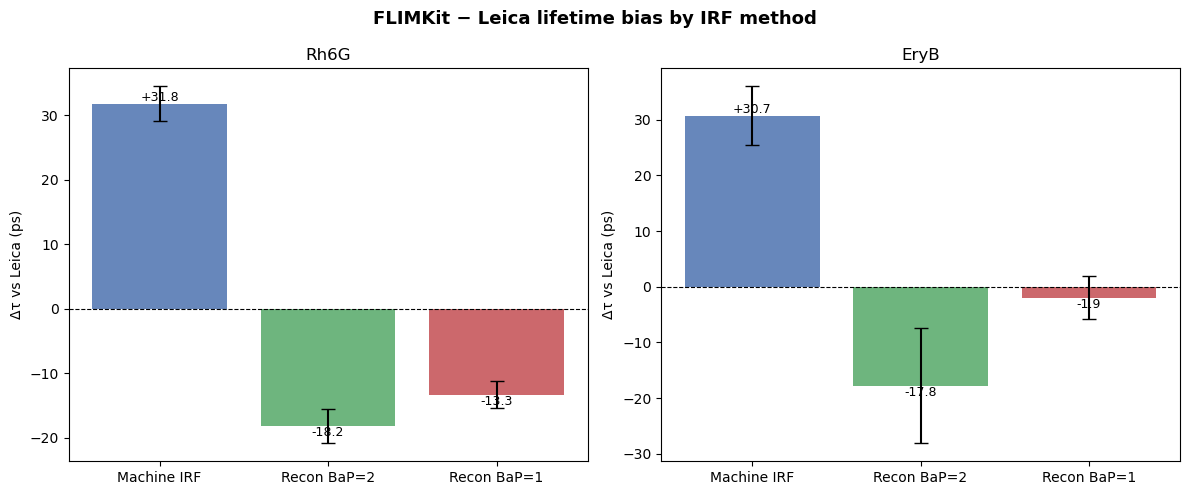

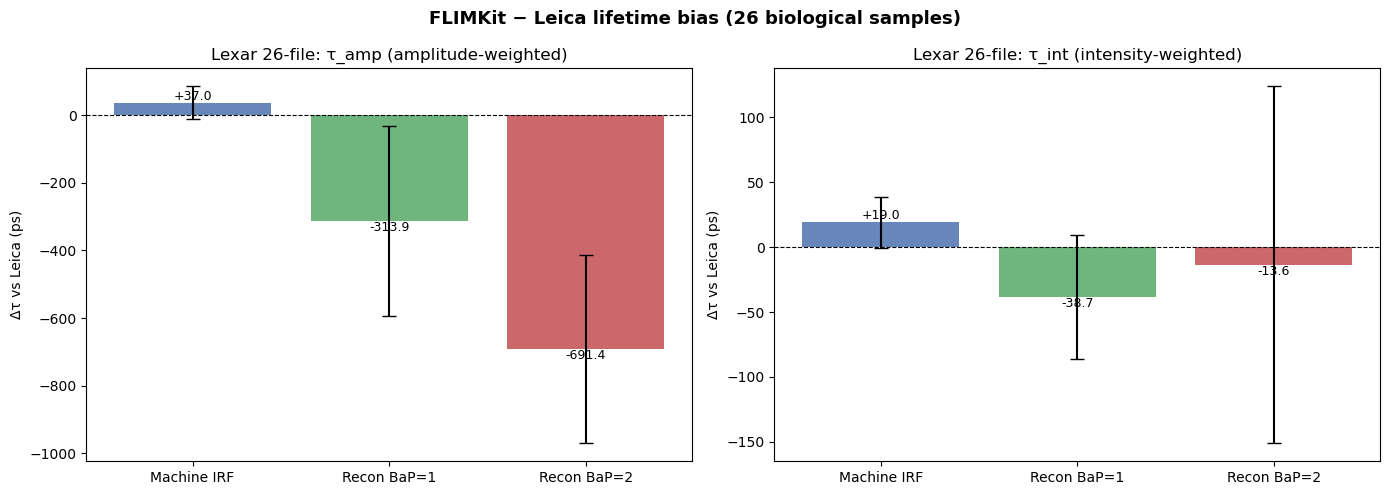

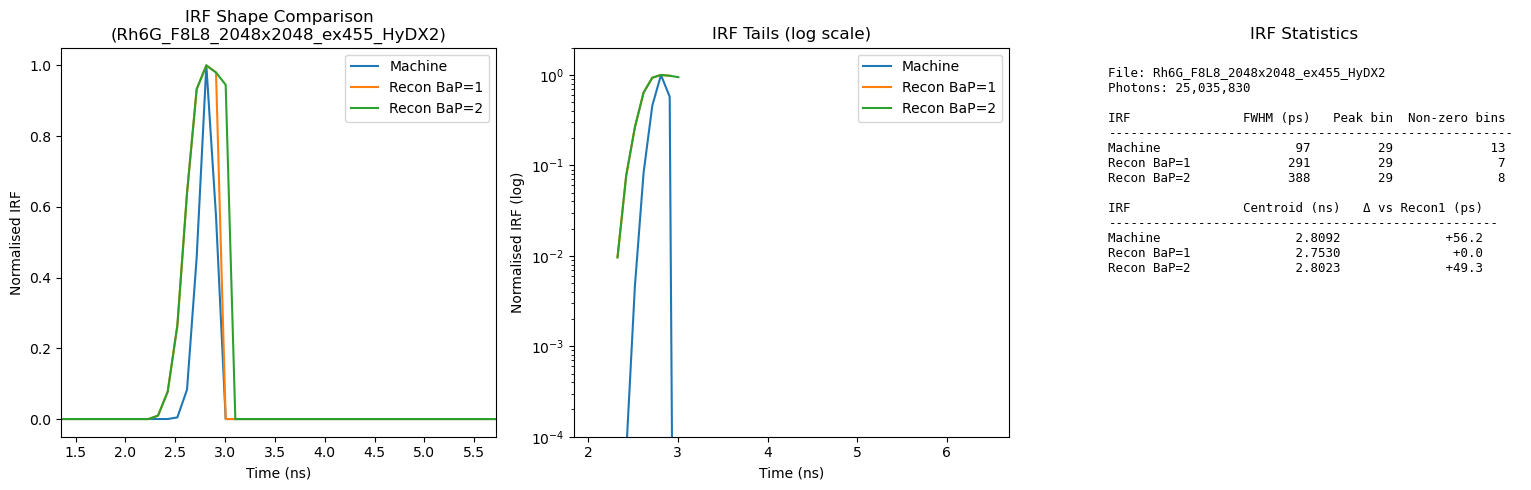

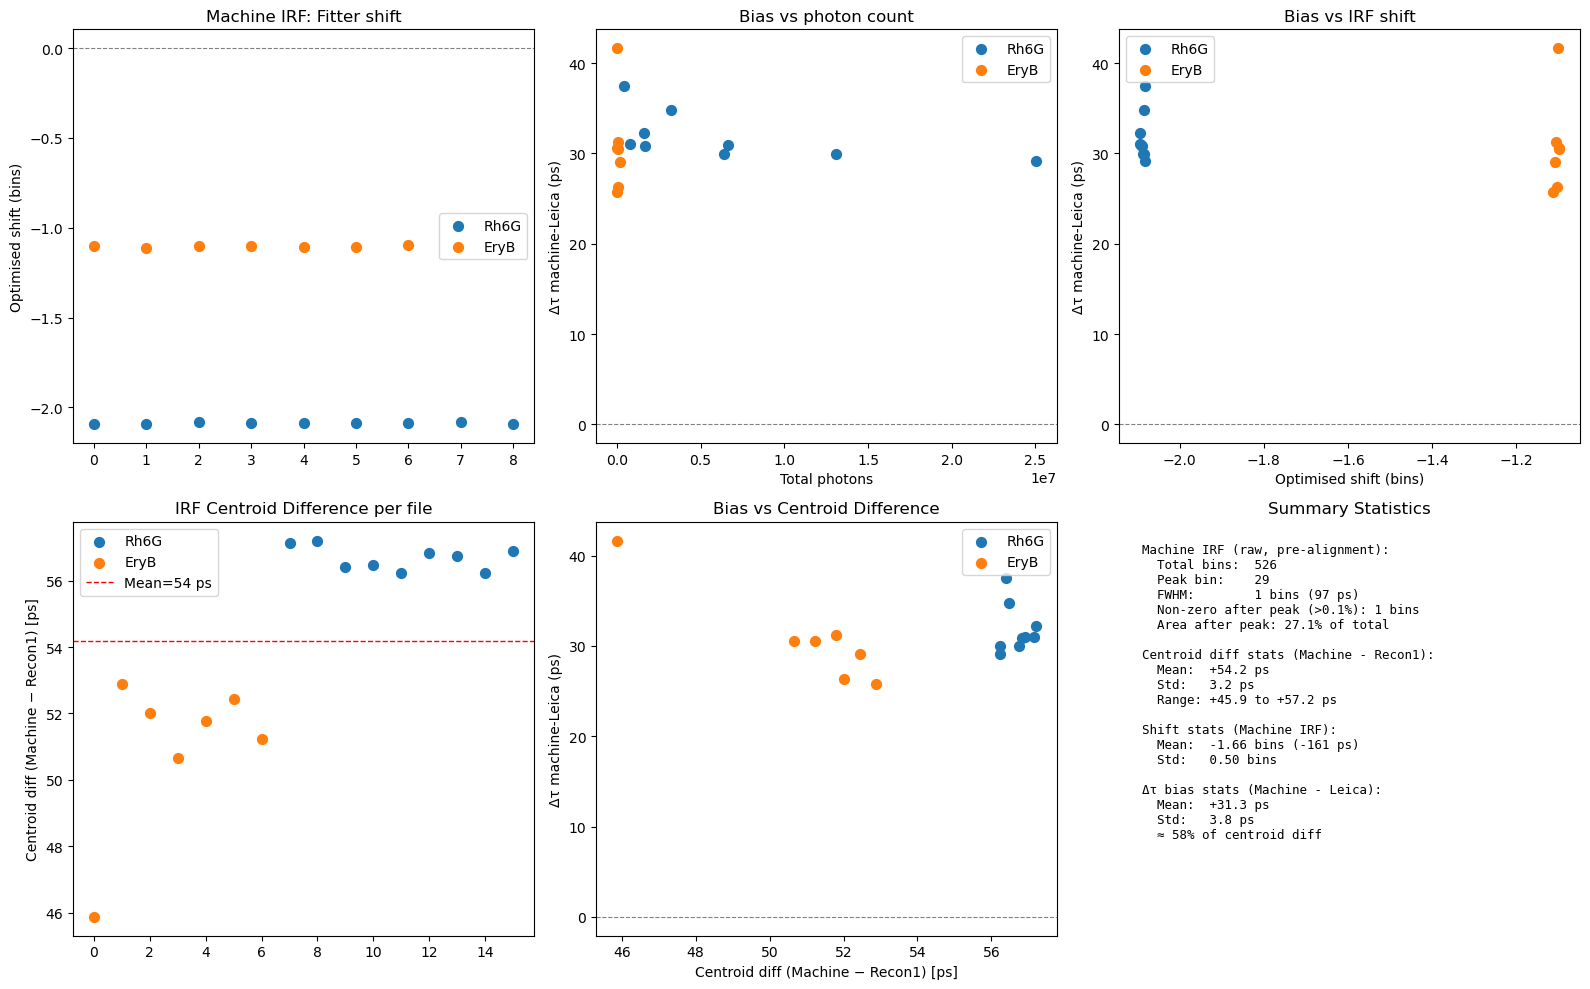

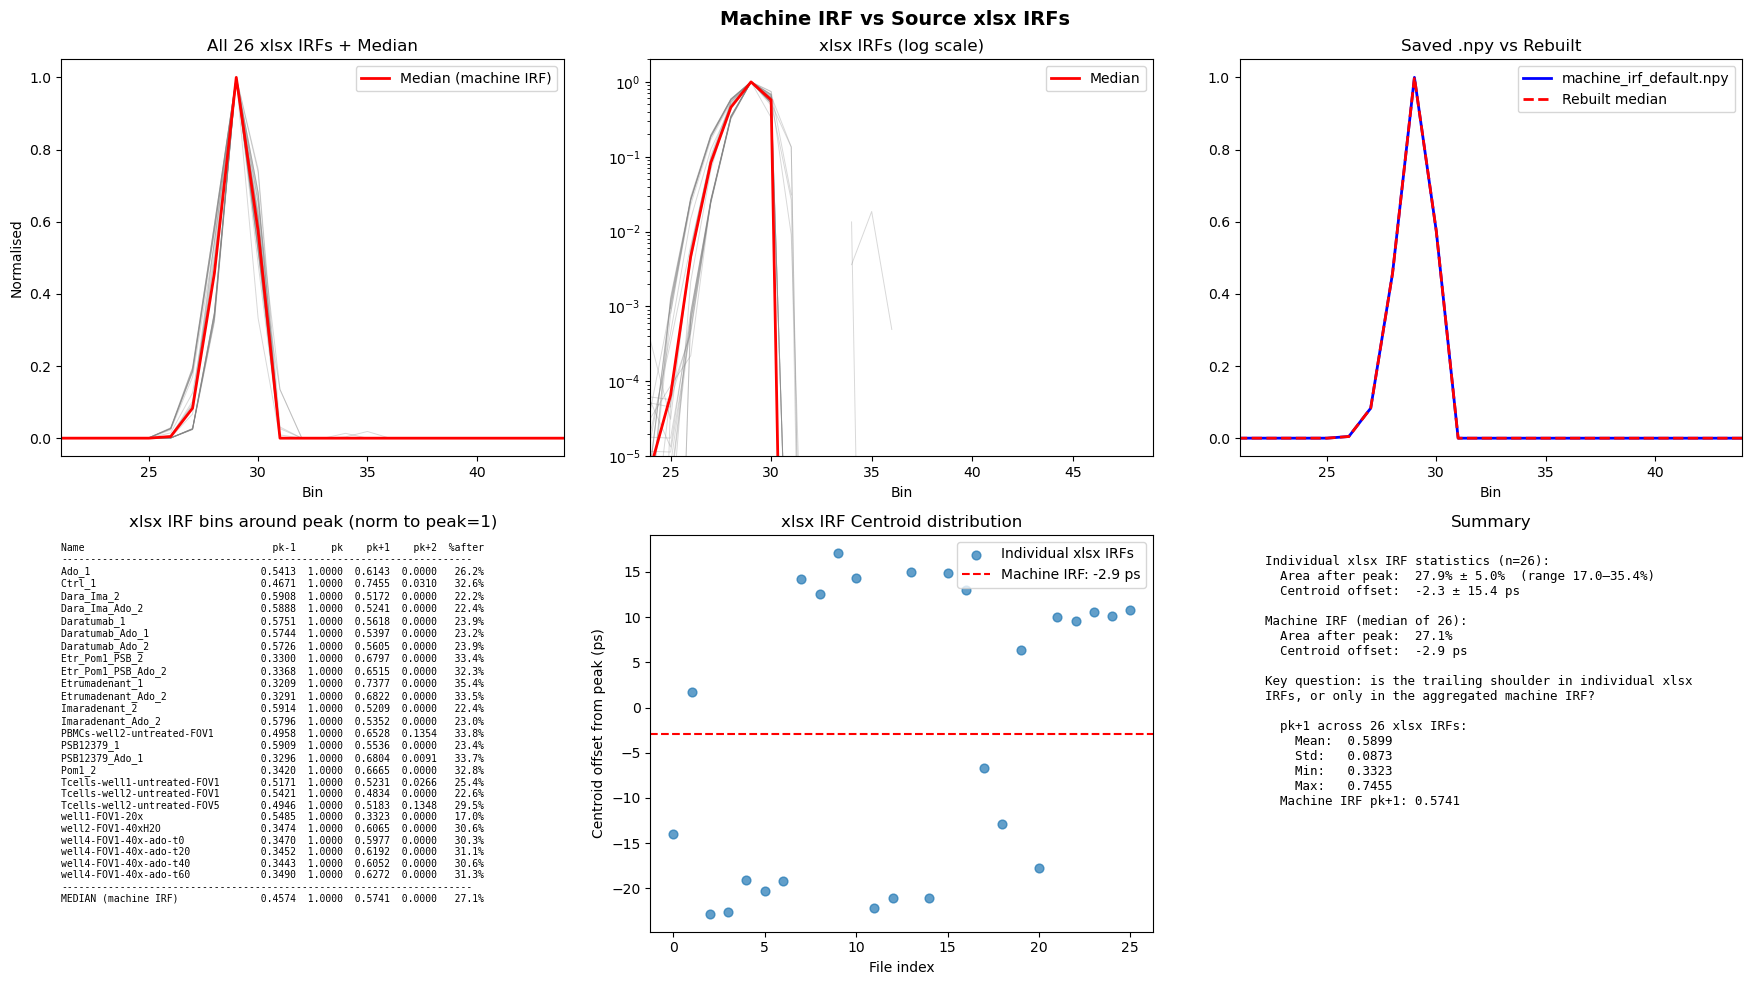

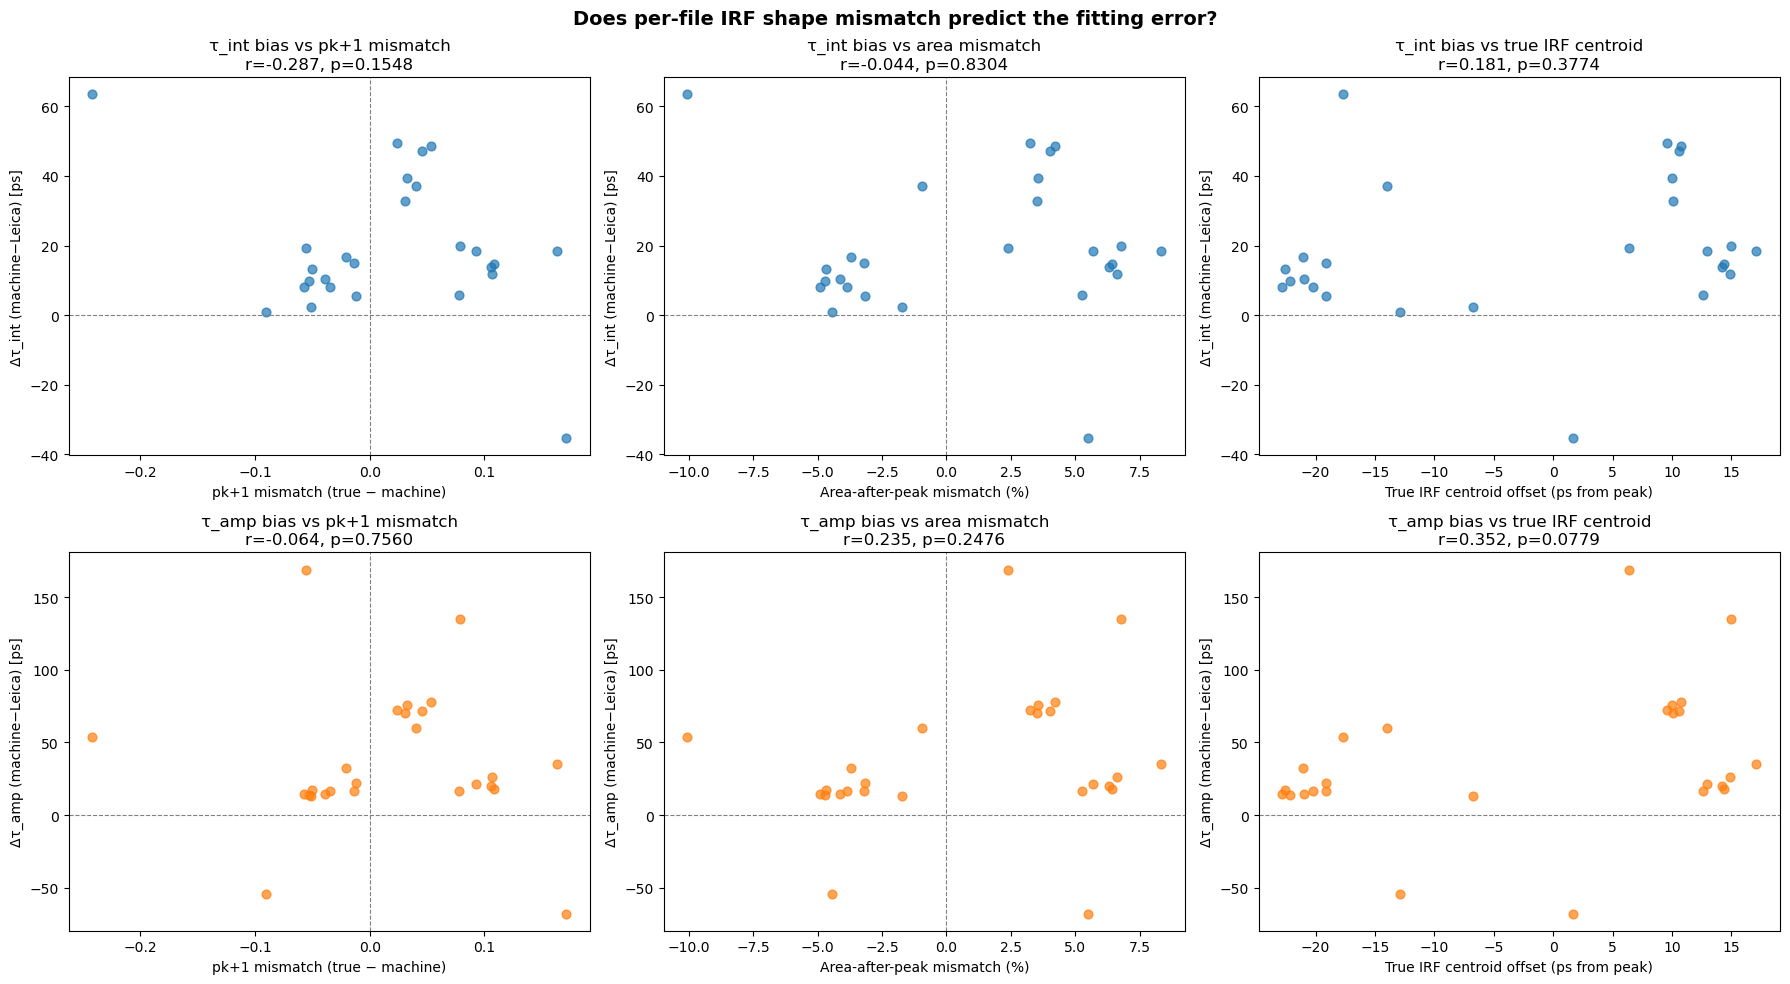

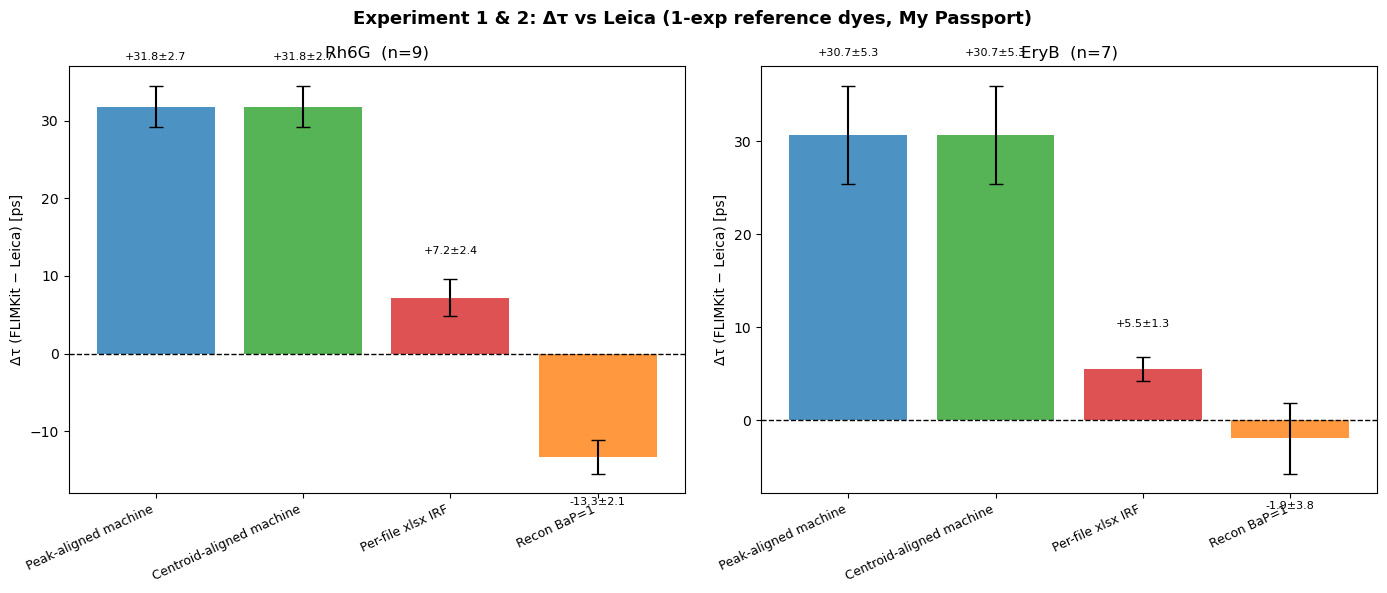

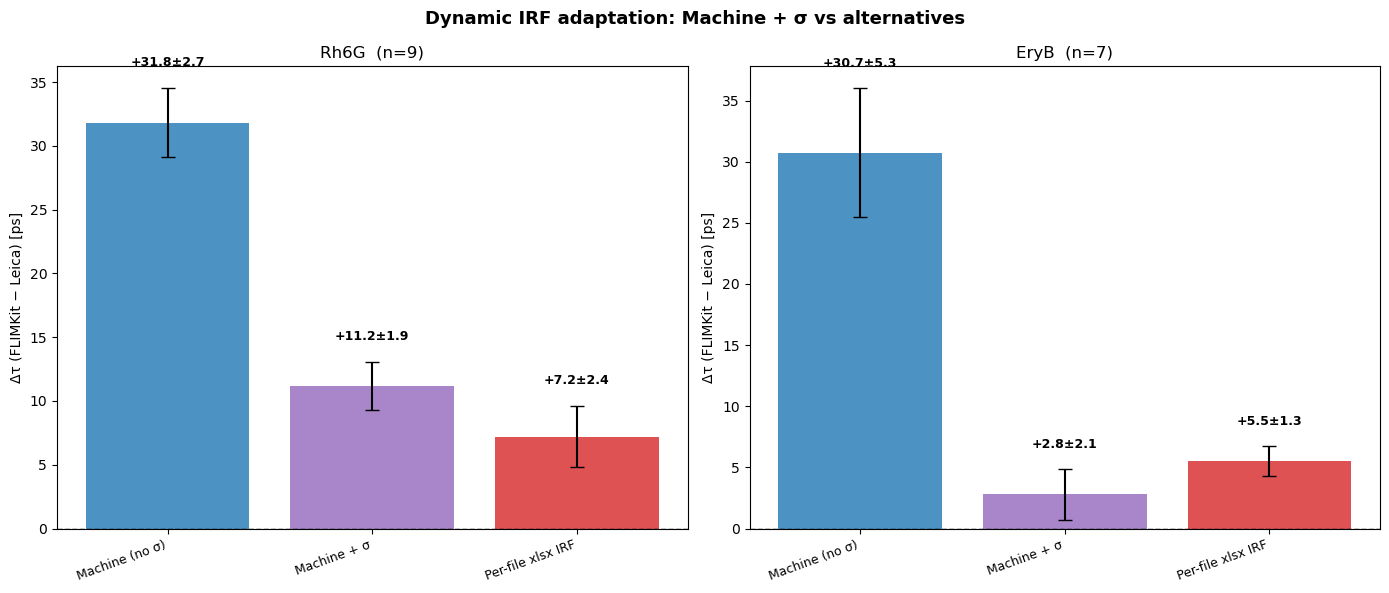

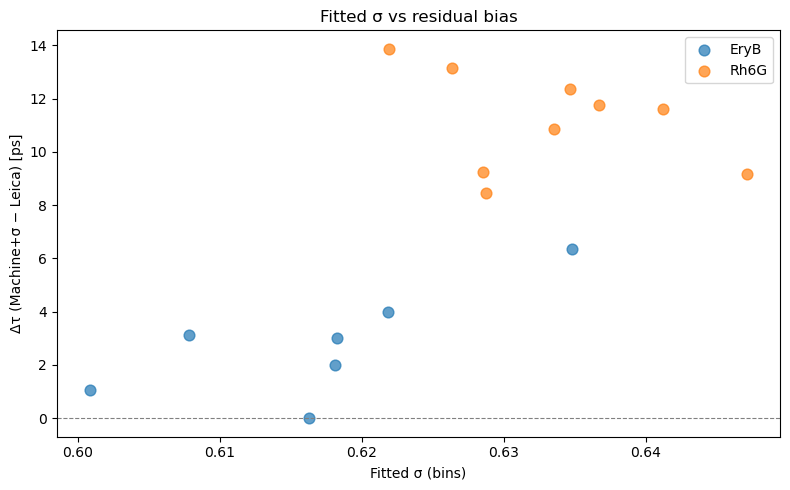

EXPERIMENT 3: DYNAMIC IRF ADAPTATION

  Rh6G (n=9):
    Method                        Mean Δτ      Std    Mean χ²     Mean σ
    ----------------------------------------------------------------
    Machine (no σ)                  +31.8      2.7      1.383          —
    Machine + σ                     +11.2      1.9      1.933          —
    Per-file xlsx IRF                +7.2      2.4      2.090          —
    Machine + σ + tail            -3506.9     31.4      1.286      0.763

  EryB (n=7):
    Method                        Mean Δτ      Std    Mean χ²     Mean σ
    ----------------------------------------------------------------
    Machine (no σ)                  +30.7      5.3      0.927          —
    Machine + σ                      +2.8      2.1      0.926          —
    Per-file xlsx IRF                +5.5      1.3      0.926          —
    Machine + σ + tail              -23.4     30.1      0.916      0.712

KEY FINDINGS:
  Machine (no σ):           +31.3 ps mean bias
  M

In [24]:
# ── Exp 3: Analysis — dynamic IRF adaptation results ─────────────────────────

# Filter out sigma+tail (catastrophic on Rh6G, unreliable)
# Focus on: Machine (no σ), Machine + σ, Per-file xlsx IRF

methods_all = [
    ("Machine (no σ)",     "base_dtau_ps",    "base_chi2"),
    ("Machine + σ",        "sigma_dtau_ps",   "sigma_chi2"),
    ("Per-file xlsx IRF",  "xlsx_dtau_ps",    "xlsx_chi2"),
]
colors_all = ["#1f77b4", "#9467bd", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, dye in enumerate(["Rh6G", "EryB"]):
    ax = axes[ax_i]
    sub = df_exp3[df_exp3["dye"] == dye]
    n = len(sub)

    means = [sub[col].mean() for _, col, _ in methods_all]
    stds  = [sub[col].std()  for _, col, _ in methods_all]
    x = np.arange(len(methods_all))

    bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors_all, alpha=0.8)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([m[0] for m in methods_all], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Δτ (FLIMKit − Leica) [ps]")
    ax.set_title(f"{dye}  (n={n})")

    for xi, m, s in zip(x, means, stds):
        y_pos = m + s + 1.5 if m >= 0 else m - s - 1.5
        ax.text(xi, y_pos, f"{m:+.1f}±{s:.1f}", ha="center",
                va="bottom" if m >= 0 else "top", fontsize=9, fontweight="bold")

plt.suptitle("Dynamic IRF adaptation: Machine + σ vs alternatives",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# === Sigma values scatter ===
fig2, ax2 = plt.subplots(figsize=(8, 5))
for dye, color in [("EryB", "tab:blue"), ("Rh6G", "tab:orange")]:
    sub = df_exp3[df_exp3["dye"] == dye]
    ax2.scatter(sub["sigma_bins"], sub["sigma_dtau_ps"], label=dye,
                s=60, alpha=0.7, color=color)
ax2.axhline(0, color="grey", ls="--", lw=0.8)
ax2.set_xlabel("Fitted σ (bins)")
ax2.set_ylabel("Δτ (Machine+σ − Leica) [ps]")
ax2.set_title("Fitted σ vs residual bias")
ax2.legend()
plt.tight_layout()
plt.show()

# === Summary table ===
print("=" * 80)
print("EXPERIMENT 3: DYNAMIC IRF ADAPTATION")
print("=" * 80)

for dye in ["Rh6G", "EryB"]:
    sub = df_exp3[df_exp3["dye"] == dye]
    n = len(sub)
    print(f"\n  {dye} (n={n}):")
    print(f"    {'Method':<26} {'Mean Δτ':>10} {'Std':>8} {'Mean χ²':>10} {'Mean σ':>10}")
    print(f"    {'-'*64}")
    for label, dtau_col, chi2_col in methods_all:
        dt_m = sub[dtau_col].mean()
        dt_s = sub[dtau_col].std()
        chi_m = sub[chi2_col].mean() if chi2_col in sub.columns else float('nan')
        print(f"    {label:<26} {dt_m:>+10.1f} {dt_s:>8.1f} {chi_m:>10.3f}", end="")
        if "sigma" in label.lower():
            sig_m = sub["sigma_bins"].mean()
            print(f" {sig_m:>10.3f}")
        else:
            print(f" {'—':>10}")

    # sigma+tail for reference (will show the catastrophe)
    st_sub = sub["sigtail_dtau_ps"]
    print(f"    {'Machine + σ + tail':<26} {st_sub.mean():>+10.1f} {st_sub.std():>8.1f} "
          f"{sub['sigtail_chi2'].mean():>10.3f} {sub['sigtail_sigma'].mean():>10.3f}")

print(f"\n{'='*80}")
print("KEY FINDINGS:")
print(f"{'='*80}")
base_all = df_exp3["base_dtau_ps"].mean()
sig_all  = df_exp3["sigma_dtau_ps"].mean()
xlsx_all = df_exp3["xlsx_dtau_ps"].mean()
print(f"  Machine (no σ):         {base_all:>+7.1f} ps mean bias")
print(f"  Machine + σ:            {sig_all:>+7.1f} ps mean bias  ← σ reduces bias {abs(base_all)/max(abs(sig_all),0.1):.0f}×")
print(f"  Per-file xlsx IRF:      {xlsx_all:>+7.1f} ps mean bias")
print(f"\n  Mean fitted σ: {df_exp3['sigma_bins'].mean():.3f} bins ({df_exp3['sigma_bins'].mean()*tcspc_ns*1000:.1f} ps)")
print(f"  σ range: {df_exp3['sigma_bins'].min():.3f} – {df_exp3['sigma_bins'].max():.3f} bins")
print(f"\n  ⚠ Machine + σ + tail: CATASTROPHIC on Rh6G (τ→0.4 ns instead of 3.9 ns)")
print(f"    The tail parameter absorbs the actual decay — too many DoF for 1-exp.")

In [25]:
# ── Exp 3b: Machine IRF + σ on Lexar bio data (3-exp) ────────────────────────

def run_fit_nexp_sigma(decay, tcspc_res, n_bins, irf_prompt, n_exp):
    """Run n-exp fit WITH fit_sigma=True."""
    params, info = fit_summed(
        decay=decay, tcspc_res=tcspc_res, n_bins=n_bins,
        irf_prompt=irf_prompt,
        has_tail=False, fit_bg=True, fit_sigma=True,
        n_exp=n_exp, tau_min_ns=0.01, tau_max_ns=20.0,
        optimizer="de", de_popsize=30, de_maxiter=5000,
        workers=-1, polish=True,
        cost_function="poisson",
    )
    return {
        "taus_ns": info["taus_ns"],
        "tau_amp_ns": info["tau_mean_amp_ns"],
        "tau_int_ns": info["tau_mean_int_ns"],
        "bg": info.get("bg_fit", None),
        "shift_bins": info["irf_shift_bins"],
        "sigma_bins": info.get("irf_sigma_bins", 0.0),
        "chi2_r_tail_pearson": info.get("reduced_chi2_tail_pearson", None),
    }

bio_sigma_results = []

for i, p in enumerate(lexar_pairs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(lexar_pairs)}] {p['name']}  ({p['n_exp']}-exp)")
    print(f"{'='*70}")

    ptu = PTUFile(str(p["ptu"]))
    decay = ptu.summed_decay()
    tcspc_res = ptu.tcspc_res
    n_bins = ptu.n_bins
    tcspc_ns = tcspc_res * 1e9
    n_exp = p["n_exp"]

    leica = read_leica_fit_multi(p["fit_xlsx"])
    print(f"  Leica: τ_amp={leica['tau_amp_ns']:.3f}, τ_int={leica['tau_int_ns']:.3f}")

    irf_machine = align_machine_irf(MACHINE_IRF, decay, n_bins)

    # Baseline: no sigma
    print(f"  --- Machine IRF (no σ) ---")
    fit_base = run_fit_nexp(decay, tcspc_res, n_bins, irf_machine, n_exp)

    # With sigma
    print(f"  --- Machine IRF + σ ---")
    fit_sig = run_fit_nexp_sigma(decay, tcspc_res, n_bins, irf_machine, n_exp)

    row = {
        "name": p["name"], "n_exp": n_exp,
        "leica_tau_amp": leica["tau_amp_ns"], "leica_tau_int": leica["tau_int_ns"],
        "base_tau_amp": fit_base["tau_amp_ns"], "base_tau_int": fit_base["tau_int_ns"],
        "base_dtau_amp_ps": (fit_base["tau_amp_ns"] - leica["tau_amp_ns"]) * 1000,
        "base_dtau_int_ps": (fit_base["tau_int_ns"] - leica["tau_int_ns"]) * 1000,
        "base_chi2": fit_base["chi2_r_tail_pearson"],
        "sig_tau_amp": fit_sig["tau_amp_ns"], "sig_tau_int": fit_sig["tau_int_ns"],
        "sig_dtau_amp_ps": (fit_sig["tau_amp_ns"] - leica["tau_amp_ns"]) * 1000,
        "sig_dtau_int_ps": (fit_sig["tau_int_ns"] - leica["tau_int_ns"]) * 1000,
        "sig_sigma": fit_sig["sigma_bins"],
        "sig_chi2": fit_sig["chi2_r_tail_pearson"],
    }
    bio_sigma_results.append(row)

    print(f"\n  {'Method':<22} {'τ_amp':>7} {'Δ_amp':>8} {'τ_int':>7} {'Δ_int':>8} {'σ':>6} {'χ²':>7}")
    print(f"  {'Leica':<22} {leica['tau_amp_ns']:>7.3f} {'—':>8} {leica['tau_int_ns']:>7.3f} {'—':>8} {'—':>6} {leica['chi2']:>7.3f}")
    da_b = (fit_base['tau_amp_ns'] - leica['tau_amp_ns']) * 1000
    di_b = (fit_base['tau_int_ns'] - leica['tau_int_ns']) * 1000
    print(f"  {'Machine (no σ)':<22} {fit_base['tau_amp_ns']:>7.3f} {da_b:>+8.1f} "
          f"{fit_base['tau_int_ns']:>7.3f} {di_b:>+8.1f} {'—':>6} {fit_base['chi2_r_tail_pearson']:>7.3f}")
    da_s = (fit_sig['tau_amp_ns'] - leica['tau_amp_ns']) * 1000
    di_s = (fit_sig['tau_int_ns'] - leica['tau_int_ns']) * 1000
    print(f"  {'Machine + σ':<22} {fit_sig['tau_amp_ns']:>7.3f} {da_s:>+8.1f} "
          f"{fit_sig['tau_int_ns']:>7.3f} {di_s:>+8.1f} {fit_sig['sigma_bins']:>6.3f} {fit_sig['chi2_r_tail_pearson']:>7.3f}")

df_bio_sig = pd.DataFrame(bio_sigma_results)
print(f"\n{'='*70}")
print(f"All {len(lexar_pairs)} Lexar bio fits complete.")


[1/26] Ado_1  (3-exp)
 
  Leica: τ_amp=1.146, τ_int=2.882
  --- Machine IRF (no σ) ---
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  --- Machine IRF + σ ---
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...

  Method                   τ_amp    Δ_amp   τ_int    Δ_int      σ      χ²
  Leica                    1.146        —   2.882        —      —   2.993
  Machine (no σ)           1.206    +59.9   2.919    +37.1      —

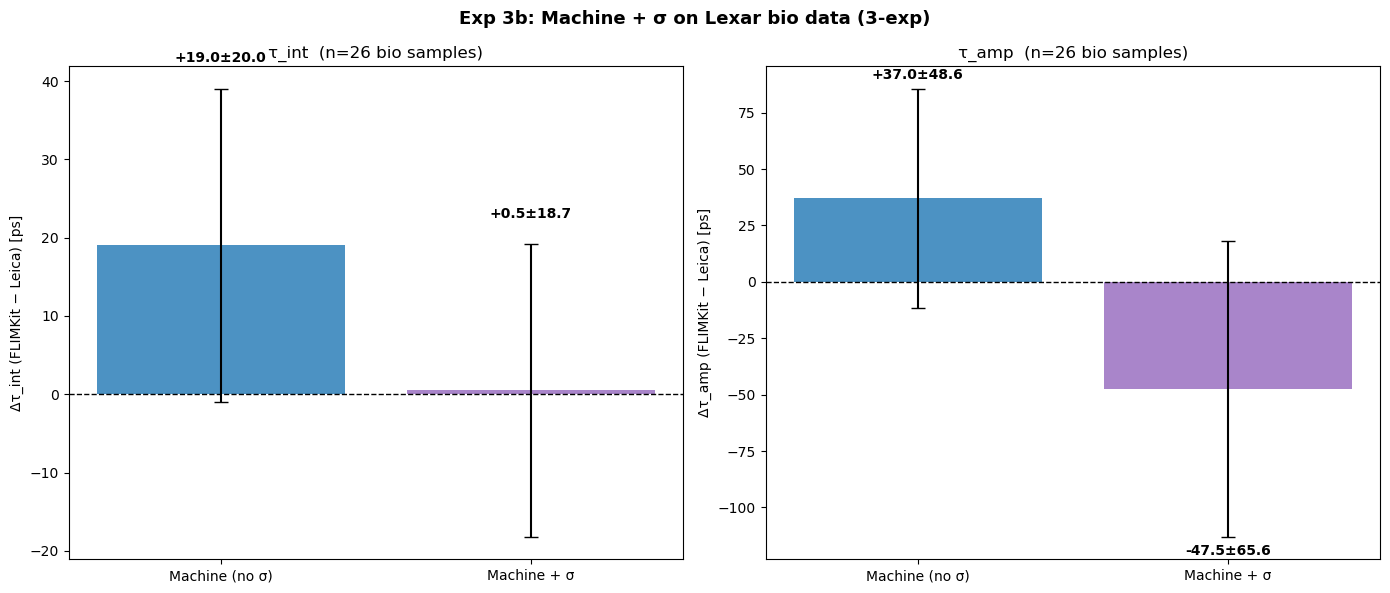

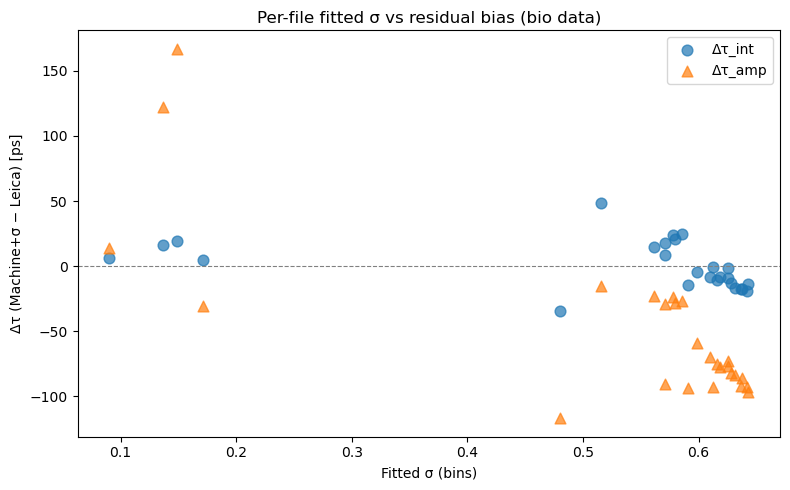

EXP 3b: MACHINE + σ ON BIO DATA (3-EXP)

  n = 26 biological samples

  Method                    Mean Δτ_int      Std    Mean Δτ_amp      Std   Mean σ    Mean χ²
  ------------------------------------------------------------------------------------
  Machine (no σ)                  +19.0     20.0          +37.0     48.6        —      1.617
  Machine + σ                      +0.5     18.7          -47.5     65.6    0.527      2.112

  σ range: 0.090 – 0.643 bins

  τ_int improvement: 19.0 → 0.5 ps  (39.5× less bias)
  τ_amp improvement: 37.0 → 47.5 ps  (0.8× less bias)


In [26]:
# ── Exp 3b: Analysis — Machine + σ on bio data ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = [
    ("τ_int", "base_dtau_int_ps", "sig_dtau_int_ps"),
    ("τ_amp", "base_dtau_amp_ps", "sig_dtau_amp_ps"),
]
methods_bio = ["Machine (no σ)", "Machine + σ"]
colors_bio = ["#1f77b4", "#9467bd"]

for ax_i, (metric_name, base_col, sig_col) in enumerate(metrics):
    ax = axes[ax_i]
    means = [df_bio_sig[base_col].mean(), df_bio_sig[sig_col].mean()]
    stds  = [df_bio_sig[base_col].std(),  df_bio_sig[sig_col].std()]
    x = np.arange(2)
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors_bio, alpha=0.8)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_bio, fontsize=10)
    ax.set_ylabel(f"Δ{metric_name} (FLIMKit − Leica) [ps]")
    ax.set_title(f"{metric_name}  (n={len(df_bio_sig)} bio samples)")
    for xi, m, s in zip(x, means, stds):
        y_pos = m + s + 3 if m >= 0 else m - s - 3
        ax.text(xi, y_pos, f"{m:+.1f}±{s:.1f}", ha="center",
                va="bottom" if m >= 0 else "top", fontsize=10, fontweight="bold")

plt.suptitle("Exp 3b: Machine + σ on Lexar bio data (3-exp)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Scatter: sigma per file
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.scatter(df_bio_sig["sig_sigma"], df_bio_sig["sig_dtau_int_ps"],
            s=60, alpha=0.7, label="Δτ_int")
ax2.scatter(df_bio_sig["sig_sigma"], df_bio_sig["sig_dtau_amp_ps"],
            s=60, alpha=0.7, marker="^", label="Δτ_amp")
ax2.axhline(0, color="grey", ls="--", lw=0.8)
ax2.set_xlabel("Fitted σ (bins)")
ax2.set_ylabel("Δτ (Machine+σ − Leica) [ps]")
ax2.set_title("Per-file fitted σ vs residual bias (bio data)")
ax2.legend()
plt.tight_layout()
plt.show()

# Summary
print("=" * 80)
print("EXP 3b: MACHINE + σ ON BIO DATA (3-EXP)")
print("=" * 80)
print(f"\n  n = {len(df_bio_sig)} biological samples")
print(f"\n  {'Method':<22} {'Mean Δτ_int':>14} {'Std':>8} {'Mean Δτ_amp':>14} {'Std':>8} {'Mean σ':>8} {'Mean χ²':>10}")
print(f"  {'-'*84}")

# No sigma
b_int_m, b_int_s = df_bio_sig["base_dtau_int_ps"].mean(), df_bio_sig["base_dtau_int_ps"].std()
b_amp_m, b_amp_s = df_bio_sig["base_dtau_amp_ps"].mean(), df_bio_sig["base_dtau_amp_ps"].std()
b_chi2 = df_bio_sig["base_chi2"].mean()
print(f"  {'Machine (no σ)':<22} {b_int_m:>+14.1f} {b_int_s:>8.1f} {b_amp_m:>+14.1f} {b_amp_s:>8.1f} {'—':>8} {b_chi2:>10.3f}")

# With sigma
s_int_m, s_int_s = df_bio_sig["sig_dtau_int_ps"].mean(), df_bio_sig["sig_dtau_int_ps"].std()
s_amp_m, s_amp_s = df_bio_sig["sig_dtau_amp_ps"].mean(), df_bio_sig["sig_dtau_amp_ps"].std()
s_chi2 = df_bio_sig["sig_chi2"].mean()
s_sig_m = df_bio_sig["sig_sigma"].mean()
print(f"  {'Machine + σ':<22} {s_int_m:>+14.1f} {s_int_s:>8.1f} {s_amp_m:>+14.1f} {s_amp_s:>8.1f} {s_sig_m:>8.3f} {s_chi2:>10.3f}")

print(f"\n  σ range: {df_bio_sig['sig_sigma'].min():.3f} – {df_bio_sig['sig_sigma'].max():.3f} bins")
print(f"\n  τ_int improvement: {abs(b_int_m):.1f} → {abs(s_int_m):.1f} ps  ({abs(b_int_m)/max(abs(s_int_m),0.1):.1f}× less bias)")
print(f"  τ_amp improvement: {abs(b_amp_m):.1f} → {abs(s_amp_m):.1f} ps  ({abs(b_amp_m)/max(abs(s_amp_m),0.1):.1f}× less bias)")

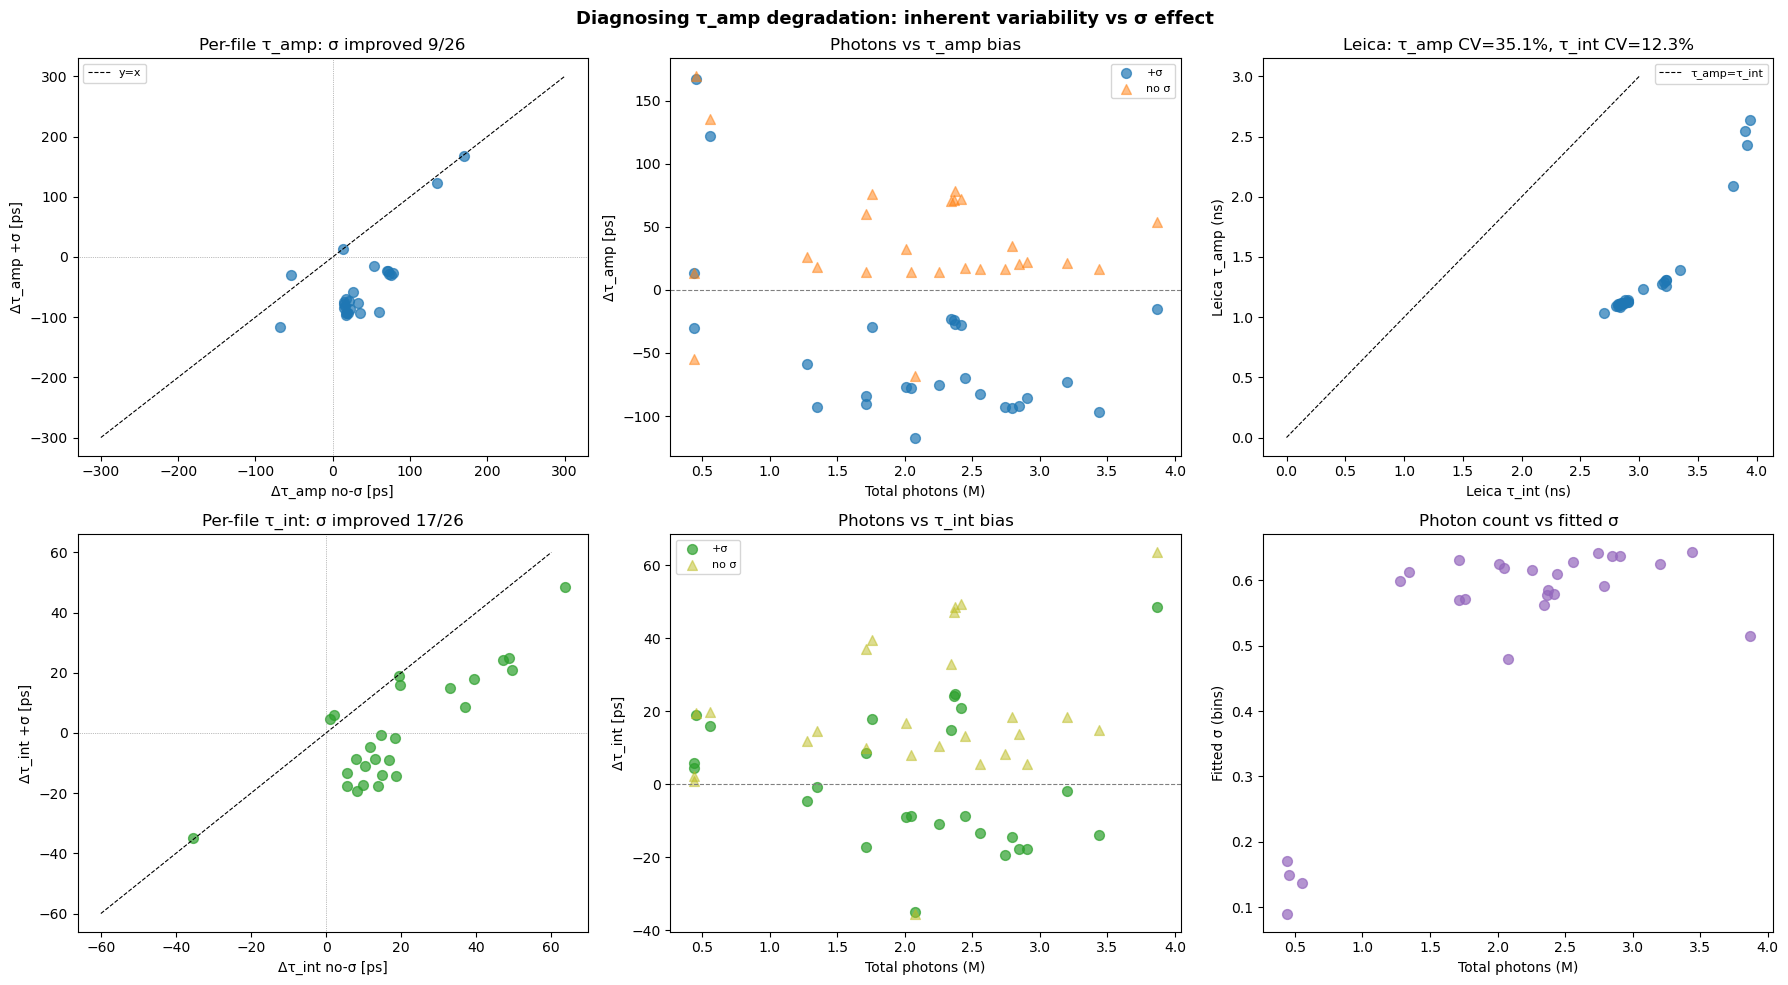

PHOTON THRESHOLD SWEEP

  Photon range: 0.44M – 3.87M
  Median: 2.30M

   Threshold    n     No-σ Δτ_amp    No-σ Δτ_int      +σ Δτ_amp      +σ Δτ_int
  --------------------------------------------------------------------------
       0.0M   26      +37.0±48.6     +19.0±20.0     -47.5±65.6      +0.5±18.7
       0.5M   23      +36.3±38.5     +20.5±20.6     -60.2±49.4      -0.7±19.4
       1.0M   22      +31.8±32.6     +20.6±21.1     -68.5±30.0      -1.5±19.5
       2.0M   17      +29.7±34.5     +20.0±23.0     -67.7±31.6      -2.2±21.3

INHERENT τ_amp VARIABILITY
  Leica τ_amp: mean=1.362 ns, std=0.478 ns, CV=35.1%
  Leica τ_int: mean=3.104 ns, std=0.383 ns, CV=12.3%

  τ_amp is 2.8× more variable than τ_int in the data itself
  τ_amp improved with σ: 9/26 files (35%)
  τ_int improved with σ: 17/26 files (65%)

  Correlation: Leica τ_amp vs σ-induced Δτ_amp change: r=0.894, p=0.0000
  Correlation: photons vs σ-induced Δτ_amp change: r=-0.659, p=0.0003


In [27]:
# ── Is τ_amp degradation inherent or σ-caused? + photon threshold ─────────────
from scipy import stats

# Merge photon counts from df_lex into df_bio_sig
df_bio_sig["photons"] = df_lex["photons"].values

# 1) How variable is Leica's own τ_amp vs τ_int?
leica_amp_cv = df_bio_sig["leica_tau_amp"].std() / df_bio_sig["leica_tau_amp"].mean() * 100
leica_int_cv = df_bio_sig["leica_tau_int"].std() / df_bio_sig["leica_tau_int"].mean() * 100

# 2) Per-file: did σ make individual files better or worse for τ_amp?
df_bio_sig["amp_improved"] = df_bio_sig["sig_dtau_amp_ps"].abs() < df_bio_sig["base_dtau_amp_ps"].abs()
df_bio_sig["int_improved"] = df_bio_sig["sig_dtau_int_ps"].abs() < df_bio_sig["base_dtau_int_ps"].abs()

# 3) Correlation: photons vs τ_amp error
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: τ_amp diagnostics
ax = axes[0, 0]
ax.scatter(df_bio_sig["base_dtau_amp_ps"], df_bio_sig["sig_dtau_amp_ps"], s=50, alpha=0.7)
lims = [-300, 300]
ax.plot(lims, lims, "k--", lw=0.8, label="y=x")
ax.axhline(0, color="grey", ls=":", lw=0.5)
ax.axvline(0, color="grey", ls=":", lw=0.5)
ax.set_xlabel("Δτ_amp no-σ [ps]")
ax.set_ylabel("Δτ_amp +σ [ps]")
ax.set_title(f"Per-file τ_amp: σ improved {df_bio_sig['amp_improved'].sum()}/{len(df_bio_sig)}")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(df_bio_sig["photons"]/1e6, df_bio_sig["sig_dtau_amp_ps"], s=50, alpha=0.7, label="+σ")
ax.scatter(df_bio_sig["photons"]/1e6, df_bio_sig["base_dtau_amp_ps"], s=50, alpha=0.5, marker="^", label="no σ")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Total photons (M)")
ax.set_ylabel("Δτ_amp [ps]")
ax.set_title("Photons vs τ_amp bias")
ax.legend(fontsize=8)

ax = axes[0, 2]
# Leica τ_amp vs τ_int scatter — show inherent variability
ax.scatter(df_bio_sig["leica_tau_int"], df_bio_sig["leica_tau_amp"], s=50, alpha=0.7)
ax.set_xlabel("Leica τ_int (ns)")
ax.set_ylabel("Leica τ_amp (ns)")
ax.set_title(f"Leica: τ_amp CV={leica_amp_cv:.1f}%, τ_int CV={leica_int_cv:.1f}%")
ax.plot([0, 3], [0, 3], "k--", lw=0.8, label="τ_amp=τ_int")
ax.legend(fontsize=8)

# Row 2: τ_int diagnostics (for comparison)
ax = axes[1, 0]
ax.scatter(df_bio_sig["base_dtau_int_ps"], df_bio_sig["sig_dtau_int_ps"], s=50, alpha=0.7, color="tab:green")
ax.plot([-60, 60], [-60, 60], "k--", lw=0.8)
ax.axhline(0, color="grey", ls=":", lw=0.5)
ax.axvline(0, color="grey", ls=":", lw=0.5)
ax.set_xlabel("Δτ_int no-σ [ps]")
ax.set_ylabel("Δτ_int +σ [ps]")
ax.set_title(f"Per-file τ_int: σ improved {df_bio_sig['int_improved'].sum()}/{len(df_bio_sig)}")

ax = axes[1, 1]
ax.scatter(df_bio_sig["photons"]/1e6, df_bio_sig["sig_dtau_int_ps"], s=50, alpha=0.7, color="tab:green", label="+σ")
ax.scatter(df_bio_sig["photons"]/1e6, df_bio_sig["base_dtau_int_ps"], s=50, alpha=0.5, marker="^", color="tab:olive", label="no σ")
ax.axhline(0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Total photons (M)")
ax.set_ylabel("Δτ_int [ps]")
ax.set_title("Photons vs τ_int bias")
ax.legend(fontsize=8)

ax = axes[1, 2]
# σ value vs photon count
ax.scatter(df_bio_sig["photons"]/1e6, df_bio_sig["sig_sigma"], s=50, alpha=0.7, color="tab:purple")
ax.set_xlabel("Total photons (M)")
ax.set_ylabel("Fitted σ (bins)")
ax.set_title("Photon count vs fitted σ")

plt.suptitle("Diagnosing τ_amp degradation: inherent variability vs σ effect",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# === Photon threshold sweep ===
print("=" * 85)
print("PHOTON THRESHOLD SWEEP")
print("=" * 85)
print(f"\n  Photon range: {df_bio_sig['photons'].min()/1e6:.2f}M – {df_bio_sig['photons'].max()/1e6:.2f}M")
print(f"  Median: {df_bio_sig['photons'].median()/1e6:.2f}M\n")

thresholds_M = [0, 0.5, 1.0, 2.0, 5.0]
print(f"  {'Threshold':>10} {'n':>4}  {'No-σ Δτ_amp':>14} {'No-σ Δτ_int':>14} "
      f"{'+σ Δτ_amp':>14} {'+σ Δτ_int':>14}")
print(f"  {'-'*74}")

for thresh in thresholds_M:
    mask = df_bio_sig["photons"] >= thresh * 1e6
    sub = df_bio_sig[mask]
    n = len(sub)
    if n < 3:
        continue
    b_amp = f"{sub['base_dtau_amp_ps'].mean():+.1f}±{sub['base_dtau_amp_ps'].std():.1f}"
    b_int = f"{sub['base_dtau_int_ps'].mean():+.1f}±{sub['base_dtau_int_ps'].std():.1f}"
    s_amp = f"{sub['sig_dtau_amp_ps'].mean():+.1f}±{sub['sig_dtau_amp_ps'].std():.1f}"
    s_int = f"{sub['sig_dtau_int_ps'].mean():+.1f}±{sub['sig_dtau_int_ps'].std():.1f}"
    print(f"  {thresh:>8.1f}M {n:>4}  {b_amp:>14} {b_int:>14} {s_amp:>14} {s_int:>14}")

# === Key diagnostics ===
print(f"\n{'='*85}")
print("INHERENT τ_amp VARIABILITY")
print(f"{'='*85}")
print(f"  Leica τ_amp: mean={df_bio_sig['leica_tau_amp'].mean():.3f} ns, "
      f"std={df_bio_sig['leica_tau_amp'].std():.3f} ns, CV={leica_amp_cv:.1f}%")
print(f"  Leica τ_int: mean={df_bio_sig['leica_tau_int'].mean():.3f} ns, "
      f"std={df_bio_sig['leica_tau_int'].std():.3f} ns, CV={leica_int_cv:.1f}%")
print(f"\n  τ_amp is {leica_amp_cv/leica_int_cv:.1f}× more variable than τ_int in the data itself")
print(f"  τ_amp improved with σ: {df_bio_sig['amp_improved'].sum()}/{len(df_bio_sig)} files "
      f"({df_bio_sig['amp_improved'].mean()*100:.0f}%)")
print(f"  τ_int improved with σ: {df_bio_sig['int_improved'].sum()}/{len(df_bio_sig)} files "
      f"({df_bio_sig['int_improved'].mean()*100:.0f}%)")

# Correlation between Leica τ_amp and the sigma-induced change
amp_change = df_bio_sig["sig_dtau_amp_ps"] - df_bio_sig["base_dtau_amp_ps"]
r_amp_change, p_amp_change = stats.pearsonr(df_bio_sig["leica_tau_amp"], amp_change)
print(f"\n  Correlation: Leica τ_amp vs σ-induced Δτ_amp change: r={r_amp_change:.3f}, p={p_amp_change:.4f}")
r_phot, p_phot = stats.pearsonr(df_bio_sig["photons"], amp_change)
print(f"  Correlation: photons vs σ-induced Δτ_amp change: r={r_phot:.3f}, p={p_phot:.4f}")

In [28]:
# ── Exp 4: Recon BaP=1 + σ on bio data (3-exp) ──────────────────────────────
# Compare 4 methods head-to-head on the 26 Lexar bio samples:
#   1. Machine IRF (no σ)          — current default
#   2. Machine IRF + σ             — best for τ_int
#   3. Recon BaP=1 (no σ)          — previous catastrophic for τ_amp
#   4. Recon BaP=1 + σ             — NEW: can σ rescue recon on multi-exp?

exp4_results = []

for i, p in enumerate(lexar_pairs):
    print(f"\n{'='*70}")
    print(f"[{i+1}/{len(lexar_pairs)}] {p['name']}  ({p['n_exp']}-exp)")
    print(f"{'='*70}")

    ptu = PTUFile(str(p["ptu"]))
    decay = ptu.summed_decay()
    tcspc_res = ptu.tcspc_res
    n_bins = ptu.n_bins
    n_exp = p["n_exp"]

    leica = read_leica_fit_multi(p["fit_xlsx"])
    print(f"  Leica: τ_amp={leica['tau_amp_ns']:.3f}, τ_int={leica['tau_int_ns']:.3f}")

    # Recon BaP=1
    irf_r1 = reconstruct_irf_from_decay(decay, tcspc_res, n_bins, max_bap=1, verbose=False)

    # Recon BaP=1 no σ
    print(f"  --- Recon BaP=1 (no σ) ---")
    fit_r1_base = run_fit_nexp(decay, tcspc_res, n_bins, irf_r1, n_exp)

    # Recon BaP=1 + σ
    print(f"  --- Recon BaP=1 + σ ---")
    fit_r1_sig = run_fit_nexp_sigma(decay, tcspc_res, n_bins, irf_r1, n_exp)

    row = {
        "name": p["name"], "n_exp": n_exp,
        "leica_tau_amp": leica["tau_amp_ns"], "leica_tau_int": leica["tau_int_ns"],
        # Recon BaP=1 no σ
        "r1_tau_amp": fit_r1_base["tau_amp_ns"], "r1_tau_int": fit_r1_base["tau_int_ns"],
        "r1_dtau_amp_ps": (fit_r1_base["tau_amp_ns"] - leica["tau_amp_ns"]) * 1000,
        "r1_dtau_int_ps": (fit_r1_base["tau_int_ns"] - leica["tau_int_ns"]) * 1000,
        "r1_chi2": fit_r1_base["chi2_r_tail_pearson"],
        # Recon BaP=1 + σ
        "r1s_tau_amp": fit_r1_sig["tau_amp_ns"], "r1s_tau_int": fit_r1_sig["tau_int_ns"],
        "r1s_dtau_amp_ps": (fit_r1_sig["tau_amp_ns"] - leica["tau_amp_ns"]) * 1000,
        "r1s_dtau_int_ps": (fit_r1_sig["tau_int_ns"] - leica["tau_int_ns"]) * 1000,
        "r1s_sigma": fit_r1_sig["sigma_bins"],
        "r1s_chi2": fit_r1_sig["chi2_r_tail_pearson"],
    }
    exp4_results.append(row)

    print(f"\n  {'Method':<22} {'τ_amp':>7} {'Δ_amp':>8} {'τ_int':>7} {'Δ_int':>8} {'σ':>6} {'χ²':>7}")
    print(f"  {'Leica':<22} {leica['tau_amp_ns']:>7.3f} {'—':>8} {leica['tau_int_ns']:>7.3f} {'—':>8} {'—':>6} {leica['chi2']:>7.3f}")
    for lbl, fit in [("Recon BaP=1", fit_r1_base), ("Recon BaP=1 + σ", fit_r1_sig)]:
        da = (fit["tau_amp_ns"] - leica["tau_amp_ns"]) * 1000
        di = (fit["tau_int_ns"] - leica["tau_int_ns"]) * 1000
        sig_str = f"{fit.get('sigma_bins', 0):.3f}" if fit.get("sigma_bins", 0) > 0 else "—"
        print(f"  {lbl:<22} {fit['tau_amp_ns']:>7.3f} {da:>+8.1f} "
              f"{fit['tau_int_ns']:>7.3f} {di:>+8.1f} {sig_str:>6} {fit['chi2_r_tail_pearson']:>7.3f}")

df_exp4 = pd.DataFrame(exp4_results)
print(f"\n{'='*70}")
print(f"All {len(lexar_pairs)} files done.")


[1/26] Ado_1  (3-exp)
 
  Leica: τ_amp=1.146, τ_int=2.882
  --- Recon BaP=1 (no σ) ---
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  --- Recon BaP=1 + σ ---
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...

  Method                   τ_amp    Δ_amp   τ_int    Δ_int      σ      χ²
  Leica                    1.146        —   2.882        —      —   2.993
  Recon BaP=1              0.957   -189.2   2.878     -3.6      —

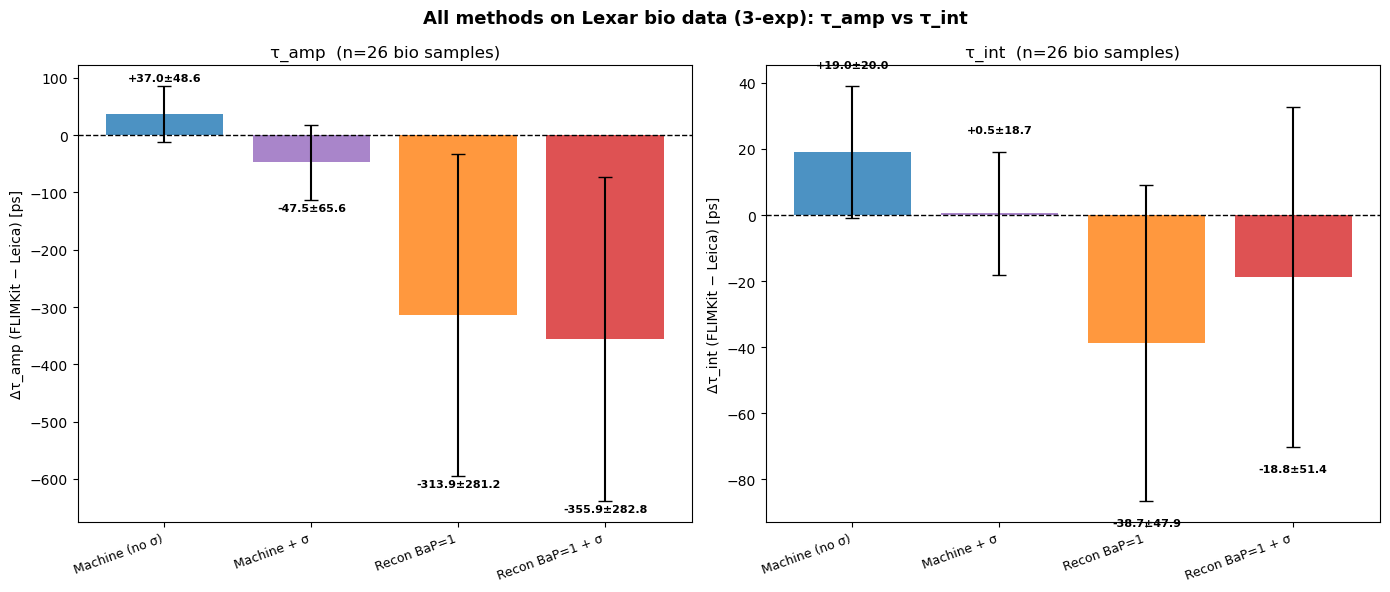

FULL COMPARISON: ALL METHODS ON BIO DATA (n=26)

  Method                    Δτ_amp (ps)      Std    Δτ_int (ps)      Std   σ (bins)
  ----------------------------------------------------------------------------
  Machine (no σ)                  +37.0     48.6          +19.0     20.0          —
  Machine + σ                     -47.5     65.6           +0.5     18.7      0.527
  Recon BaP=1                    -313.9    281.2          -38.7     47.9          —
  Recon BaP=1 + σ                -355.9    282.8          -18.8     51.4      0.167

WINNERS:
  Lowest |Δτ_int| bias:  Machine + σ  (+0.5 ps)
  Lowest |Δτ_amp| bias:  Machine (no σ)  (+37.0 ps)
  Lowest τ_int scatter:  Machine + σ  (±18.7 ps)
  Lowest τ_amp scatter:  Machine (no σ)  (±48.6 ps)


In [29]:
# ── Exp 4: Full comparison — all methods on bio data ─────────────────────────

# Merge machine results from df_bio_sig
df_exp4["mach_dtau_amp_ps"] = df_bio_sig["base_dtau_amp_ps"].values
df_exp4["mach_dtau_int_ps"] = df_bio_sig["base_dtau_int_ps"].values
df_exp4["machs_dtau_amp_ps"] = df_bio_sig["sig_dtau_amp_ps"].values
df_exp4["machs_dtau_int_ps"] = df_bio_sig["sig_dtau_int_ps"].values

methods_4 = [
    ("Machine (no σ)",  "mach_dtau_amp_ps",  "mach_dtau_int_ps"),
    ("Machine + σ",     "machs_dtau_amp_ps", "machs_dtau_int_ps"),
    ("Recon BaP=1",     "r1_dtau_amp_ps",    "r1_dtau_int_ps"),
    ("Recon BaP=1 + σ", "r1s_dtau_amp_ps",   "r1s_dtau_int_ps"),
]
colors_4 = ["#1f77b4", "#9467bd", "#ff7f0e", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_i, (metric_label, amp_or_int) in enumerate([("τ_amp", 1), ("τ_int", 2)]):
    ax = axes[ax_i]
    col_idx = amp_or_int  # 1=amp col, 2=int col
    vals = []
    errs = []
    for label, amp_col, int_col in methods_4:
        col = amp_col if amp_or_int == 1 else int_col
        vals.append(df_exp4[col].mean())
        errs.append(df_exp4[col].std())

    x = np.arange(len(methods_4))
    bars = ax.bar(x, vals, yerr=errs, capsize=5, color=colors_4, alpha=0.8)
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([m[0] for m in methods_4], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(f"Δ{metric_label} (FLIMKit − Leica) [ps]")
    ax.set_title(f"{metric_label}  (n={len(df_exp4)} bio samples)")

    for xi, m, s in zip(x, vals, errs):
        y_pos = m + s + 5 if m >= 0 else m - s - 5
        ax.text(xi, y_pos, f"{m:+.1f}±{s:.1f}", ha="center",
                va="bottom" if m >= 0 else "top", fontsize=8, fontweight="bold")

plt.suptitle("All methods on Lexar bio data (3-exp): τ_amp vs τ_int",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary table
print("=" * 90)
print("FULL COMPARISON: ALL METHODS ON BIO DATA (n=26)")
print("=" * 90)
print(f"\n  {'Method':<22} {'Δτ_amp (ps)':>14} {'Std':>8} {'Δτ_int (ps)':>14} {'Std':>8} {'σ (bins)':>10}")
print(f"  {'-'*76}")
for label, amp_col, int_col in methods_4:
    a_m = df_exp4[amp_col].mean()
    a_s = df_exp4[amp_col].std()
    i_m = df_exp4[int_col].mean()
    i_s = df_exp4[int_col].std()
    sig_str = "—"
    if "machs" in amp_col:
        sig_str = f"{df_bio_sig['sig_sigma'].mean():.3f}"
    elif "r1s" in amp_col:
        sig_str = f"{df_exp4['r1s_sigma'].mean():.3f}"
    print(f"  {label:<22} {a_m:>+14.1f} {a_s:>8.1f} {i_m:>+14.1f} {i_s:>8.1f} {sig_str:>10}")

# Winner per metric
print(f"\n{'='*90}")
print("WINNERS:")
print(f"{'='*90}")
best_int = min(methods_4, key=lambda m: abs(df_exp4[m[2]].mean()))
best_amp = min(methods_4, key=lambda m: abs(df_exp4[m[1]].mean()))
best_int_std = min(methods_4, key=lambda m: df_exp4[m[2]].std())
best_amp_std = min(methods_4, key=lambda m: df_exp4[m[1]].std())
print(f"  Lowest |Δτ_int| bias:  {best_int[0]}  ({df_exp4[best_int[2]].mean():+.1f} ps)")
print(f"  Lowest |Δτ_amp| bias:  {best_amp[0]}  ({df_exp4[best_amp[1]].mean():+.1f} ps)")
print(f"  Lowest τ_int scatter:  {best_int_std[0]}  (±{df_exp4[best_int_std[2]].std():.1f} ps)")
print(f"  Lowest τ_amp scatter:  {best_amp_std[0]}  (±{df_exp4[best_amp_std[1]].std():.1f} ps)")

In [33]:
# ── Exp 5: σ_max sweep on BOTH chems (1-exp) and bio (3-exp) ─────────────────
# Monkey-patch _build_bounds in BOTH fit_tools AND fitters (which imports it directly)
from flimkit.FLIM import fit_tools as _ft
from flimkit.FLIM import fitters as _fitters
_original_build_bounds = _ft._build_bounds

sigma_caps = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0]

sweep_bio = {}   # sigma_cap -> list of per-file dicts
sweep_chem = {}  # sigma_cap -> list of per-file dicts

for sigma_cap in sigma_caps:
    print(f"\n{'#'*70}")
    print(f"  σ_max = {sigma_cap:.2f} bins")
    print(f"{'#'*70}")

    def _patched_build_bounds(n_exp, tau_min, tau_max, decay_peak,
                              has_tail, fit_bg, fit_sigma, bg_init=0.0, bg_upper=None,
                              _cap=sigma_cap):
        lo, hi = _original_build_bounds(n_exp, tau_min, tau_max, decay_peak,
                                        has_tail, fit_bg, fit_sigma, bg_init, bg_upper)
        if fit_sigma:
            sig_idx = 2 * n_exp + 1
            hi[sig_idx] = _cap
        return lo, hi

    # Patch BOTH references
    _ft._build_bounds = _patched_build_bounds
    _fitters._build_bounds = _patched_build_bounds

    # ── Chems (1-exp, 16 files) ──
    print(f"  --- Chems (1-exp, {len(pairs)} files) ---")
    chem_results = []
    for i, p in enumerate(pairs):
        ptu = PTUFile(str(p["ptu"]))
        decay = ptu.summed_decay()
        tcspc_res = ptu.tcspc_res
        n_bins = ptu.n_bins
        leica = read_leica_fit(p["fit_xlsx"])
        irf_machine = align_machine_irf(MACHINE_IRF, decay, n_bins)
        fit = run_fit_dynamic(decay, tcspc_res, n_bins, irf_machine,
                              fit_sigma=True, has_tail=False)
        dt = (fit["tau_ns"] - leica["tau_ns"]) * 1000
        chem_results.append({"name": p["name"], "dye": p["dye"],
                             "dtau_ps": dt, "sigma": fit["sigma_bins"]})
        print(f"    [{i+1:2d}] {p['name'][:30]:<30} Δτ={dt:+7.1f}  σ={fit['sigma_bins']:.3f}")
    sweep_chem[sigma_cap] = chem_results

    # ── Bio (3-exp, 26 files) ──
    print(f"  --- Bio (3-exp, {len(lexar_pairs)} files) ---")
    bio_results = []
    for i, p in enumerate(lexar_pairs):
        ptu = PTUFile(str(p["ptu"]))
        decay = ptu.summed_decay()
        tcspc_res = ptu.tcspc_res
        n_bins = ptu.n_bins
        n_exp = p["n_exp"]
        leica = read_leica_fit_multi(p["fit_xlsx"])
        irf_machine = align_machine_irf(MACHINE_IRF, decay, n_bins)
        fit = run_fit_nexp_sigma(decay, tcspc_res, n_bins, irf_machine, n_exp)
        da = (fit["tau_amp_ns"] - leica["tau_amp_ns"]) * 1000
        di = (fit["tau_int_ns"] - leica["tau_int_ns"]) * 1000
        bio_results.append({"name": p["name"], "dtau_amp_ps": da, "dtau_int_ps": di,
                            "sigma": fit["sigma_bins"]})
        print(f"    [{i+1:2d}] {p['name'][:30]:<30} Δamp={da:+7.1f}  Δint={di:+7.1f}  σ={fit['sigma_bins']:.3f}")
    sweep_bio[sigma_cap] = bio_results

# Restore original in BOTH places
_ft._build_bounds = _original_build_bounds
_fitters._build_bounds = _original_build_bounds
print(f"\n{'='*70}")
print("σ_max sweep complete (both datasets).")


######################################################################
  σ_max = 0.10 bins
######################################################################
  --- Chems (1-exp, 16 files) ---
 
  Next-period artefact at bin 485 (47.03 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 0.000 cts/bin, upper bound = 10.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
    [ 1] EryB_F2L2_512x512_ex455_HyDX2  Δτ=  +41.9  σ=0.036
 
  Next-period artefact at bin 489 (47.42 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 4.000 cts/bin, upper bound = 14.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
    [ 2] EryB_F4L4_1024x1024_ex455_HyDX Δτ=  +25.6  σ=0.019
 
  Next-pe

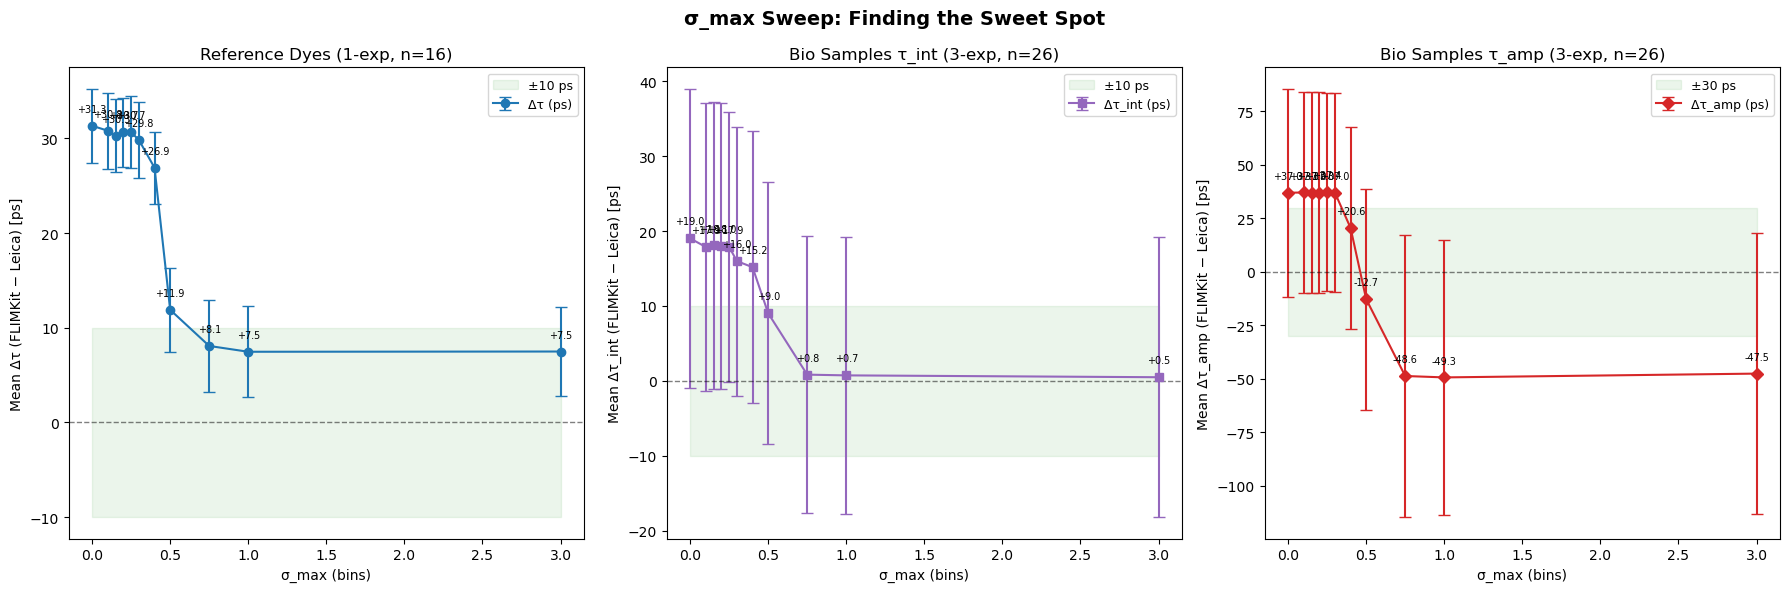

σ_max SWEEP SUMMARY

   σ_max │   Chems Δτ   ±    std │  Bio Δτ_int   ±    std │  Bio Δτ_amp   ±    std │ Mean σ_fit
  ───────┼───────────────────────┼────────────────────────┼────────────────────────┼───────────
     off │      +31.3      3.9 │       +19.0     20.0 │       +37.0     48.6 │          —
    0.10 │      +30.8      4.0 │       +17.9     19.2 │       +37.1     47.1 │      0.053
    0.15 │      +30.3      3.8 │       +18.1     19.2 │       +37.0     47.1 │      0.076
    0.20 │      +30.7      3.6 │       +18.0     19.1 │       +37.0     47.1 │      0.101
    0.25 │      +30.7      3.8 │       +17.9     18.0 │       +37.4     46.4 │      0.169
    0.30 │      +29.8      4.0 │       +16.0     18.0 │       +37.0     46.5 │      0.276
    0.40 │      +26.9      3.8 │       +15.2     18.2 │       +20.6     47.2 │      0.356
    0.50 │      +11.9      4.5 │        +9.0     17.5 │       -12.7     51.6 │      0.446
    0.75 │       +8.1      4.9 │        +0.8     18.5 │       -48.6

In [34]:
# ── Exp 5: Analysis — σ_max sweep results (both datasets) ────────────────────

# Build summary: include σ=0 (no sigma) and σ≤3.0 (uncapped) from earlier experiments
# Chems baseline (no σ): from df_exp3
chem_no_sig_mean = df_exp3["base_dtau_ps"].mean()
chem_no_sig_std  = df_exp3["base_dtau_ps"].std()
# Chems σ≤3.0 (uncapped): from df_exp3
chem_uncapped_mean = df_exp3["sigma_dtau_ps"].mean()
chem_uncapped_std  = df_exp3["sigma_dtau_ps"].std()

# Bio baseline (no σ): from df_bio_sig
bio_no_sig_amp_mean = df_bio_sig["base_dtau_amp_ps"].mean()
bio_no_sig_amp_std  = df_bio_sig["base_dtau_amp_ps"].std()
bio_no_sig_int_mean = df_bio_sig["base_dtau_int_ps"].mean()
bio_no_sig_int_std  = df_bio_sig["base_dtau_int_ps"].std()
# Bio σ≤3.0 (uncapped): from df_bio_sig
bio_uncapped_amp_mean = df_bio_sig["sig_dtau_amp_ps"].mean()
bio_uncapped_amp_std  = df_bio_sig["sig_dtau_amp_ps"].std()
bio_uncapped_int_mean = df_bio_sig["sig_dtau_int_ps"].mean()
bio_uncapped_int_std  = df_bio_sig["sig_dtau_int_ps"].std()

# Collect sweep points
all_caps = [0.0] + sorted(sigma_caps) + [3.0]

chem_means = [chem_no_sig_mean]
chem_stds  = [chem_no_sig_std]
chem_sig_means = [0.0]
for cap in sorted(sigma_caps):
    res = sweep_chem[cap]
    vals = [r["dtau_ps"] for r in res]
    sigs = [r["sigma"] for r in res]
    chem_means.append(np.mean(vals))
    chem_stds.append(np.std(vals))
    chem_sig_means.append(np.mean(sigs))
chem_means.append(chem_uncapped_mean)
chem_stds.append(chem_uncapped_std)
chem_sig_means.append(df_exp3["sigma_bins"].mean())

bio_amp_means = [bio_no_sig_amp_mean]
bio_amp_stds  = [bio_no_sig_amp_std]
bio_int_means = [bio_no_sig_int_mean]
bio_int_stds  = [bio_no_sig_int_std]
bio_sig_means = [0.0]
for cap in sorted(sigma_caps):
    res = sweep_bio[cap]
    a_vals = [r["dtau_amp_ps"] for r in res]
    i_vals = [r["dtau_int_ps"] for r in res]
    sigs = [r["sigma"] for r in res]
    bio_amp_means.append(np.mean(a_vals))
    bio_amp_stds.append(np.std(a_vals))
    bio_int_means.append(np.mean(i_vals))
    bio_int_stds.append(np.std(i_vals))
    bio_sig_means.append(np.mean(sigs))
bio_amp_means.append(bio_uncapped_amp_mean)
bio_amp_stds.append(bio_uncapped_amp_std)
bio_int_means.append(bio_uncapped_int_mean)
bio_int_stds.append(bio_uncapped_int_std)
bio_sig_means.append(df_bio_sig["sig_sigma"].mean())

# Convert to arrays
all_caps = np.array(all_caps)
chem_means = np.array(chem_means)
chem_stds = np.array(chem_stds)
bio_amp_means = np.array(bio_amp_means)
bio_amp_stds = np.array(bio_amp_stds)
bio_int_means = np.array(bio_int_means)
bio_int_stds = np.array(bio_int_stds)

# ── 3-panel plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Chems (1-exp) — single τ
ax = axes[0]
ax.errorbar(all_caps, chem_means, yerr=chem_stds, fmt="o-", color="#1f77b4",
            capsize=4, markersize=6, label="Δτ (ps)")
ax.axhline(0, color="black", ls="--", lw=1, alpha=0.5)
ax.fill_between(all_caps, -10, 10, color="green", alpha=0.08, label="±10 ps")
ax.set_xlabel("σ_max (bins)")
ax.set_ylabel("Mean Δτ (FLIMKit − Leica) [ps]")
ax.set_title(f"Reference Dyes (1-exp, n={len(pairs)})")
ax.legend(fontsize=9)
for i, cap in enumerate(all_caps):
    ax.annotate(f"{chem_means[i]:+.1f}", (cap, chem_means[i]),
                textcoords="offset points", xytext=(0, 10), fontsize=7, ha="center")

# Panel 2: Bio — τ_int
ax = axes[1]
ax.errorbar(all_caps, bio_int_means, yerr=bio_int_stds, fmt="s-", color="#9467bd",
            capsize=4, markersize=6, label="Δτ_int (ps)")
ax.axhline(0, color="black", ls="--", lw=1, alpha=0.5)
ax.fill_between(all_caps, -10, 10, color="green", alpha=0.08, label="±10 ps")
ax.set_xlabel("σ_max (bins)")
ax.set_ylabel("Mean Δτ_int (FLIMKit − Leica) [ps]")
ax.set_title(f"Bio Samples τ_int (3-exp, n={len(lexar_pairs)})")
ax.legend(fontsize=9)
for i, cap in enumerate(all_caps):
    ax.annotate(f"{bio_int_means[i]:+.1f}", (cap, bio_int_means[i]),
                textcoords="offset points", xytext=(0, 10), fontsize=7, ha="center")

# Panel 3: Bio — τ_amp
ax = axes[2]
ax.errorbar(all_caps, bio_amp_means, yerr=bio_amp_stds, fmt="D-", color="#d62728",
            capsize=4, markersize=6, label="Δτ_amp (ps)")
ax.axhline(0, color="black", ls="--", lw=1, alpha=0.5)
ax.fill_between(all_caps, -30, 30, color="green", alpha=0.08, label="±30 ps")
ax.set_xlabel("σ_max (bins)")
ax.set_ylabel("Mean Δτ_amp (FLIMKit − Leica) [ps]")
ax.set_title(f"Bio Samples τ_amp (3-exp, n={len(lexar_pairs)})")
ax.legend(fontsize=9)
for i, cap in enumerate(all_caps):
    ax.annotate(f"{bio_amp_means[i]:+.1f}", (cap, bio_amp_means[i]),
                textcoords="offset points", xytext=(0, 10), fontsize=7, ha="center")

plt.suptitle("σ_max Sweep: Finding the Sweet Spot", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary table ──
print("=" * 100)
print("σ_max SWEEP SUMMARY")
print("=" * 100)
print(f"\n  {'σ_max':>6} │ {'Chems Δτ':>10} {'±':>3} {'std':>6} │ "
      f"{'Bio Δτ_int':>11} {'±':>3} {'std':>6} │ "
      f"{'Bio Δτ_amp':>11} {'±':>3} {'std':>6} │ {'Mean σ_fit':>10}")
print(f"  {'─'*6}─┼─{'─'*21}─┼─{'─'*22}─┼─{'─'*22}─┼─{'─'*10}")
for i, cap in enumerate(all_caps):
    cap_str = "off" if cap == 0 else f"{cap:.2f}" if cap < 3 else "3.00"
    print(f"  {cap_str:>6} │ {chem_means[i]:>+10.1f}   {chem_stds[i]:>6.1f} │ "
          f"{bio_int_means[i]:>+11.1f}   {bio_int_stds[i]:>6.1f} │ "
          f"{bio_amp_means[i]:>+11.1f}   {bio_amp_stds[i]:>6.1f} │ "
          f"{bio_sig_means[i]:>10.3f}" if i > 0 else
          f"  {cap_str:>6} │ {chem_means[i]:>+10.1f}   {chem_stds[i]:>6.1f} │ "
          f"{bio_int_means[i]:>+11.1f}   {bio_int_stds[i]:>6.1f} │ "
          f"{bio_amp_means[i]:>+11.1f}   {bio_amp_stds[i]:>6.1f} │ {'—':>10}")

# Best combined score: minimize sum of absolute biases across all 3 metrics
print(f"\n{'='*100}")
print("OPTIMAL σ_max (minimises |Δ| across all 3 metrics):")
combined_score = np.abs(chem_means) + np.abs(bio_int_means) + np.abs(bio_amp_means)
best_idx = np.argmin(combined_score)
print(f"  σ_max = {all_caps[best_idx]:.2f} bins")
print(f"    Chems Δτ   = {chem_means[best_idx]:+.1f} ± {chem_stds[best_idx]:.1f} ps")
print(f"    Bio Δτ_int = {bio_int_means[best_idx]:+.1f} ± {bio_int_stds[best_idx]:.1f} ps")
print(f"    Bio Δτ_amp = {bio_amp_means[best_idx]:+.1f} ± {bio_amp_stds[best_idx]:.1f} ps")
print(f"    Combined |Δ| = {combined_score[best_idx]:.1f} ps")

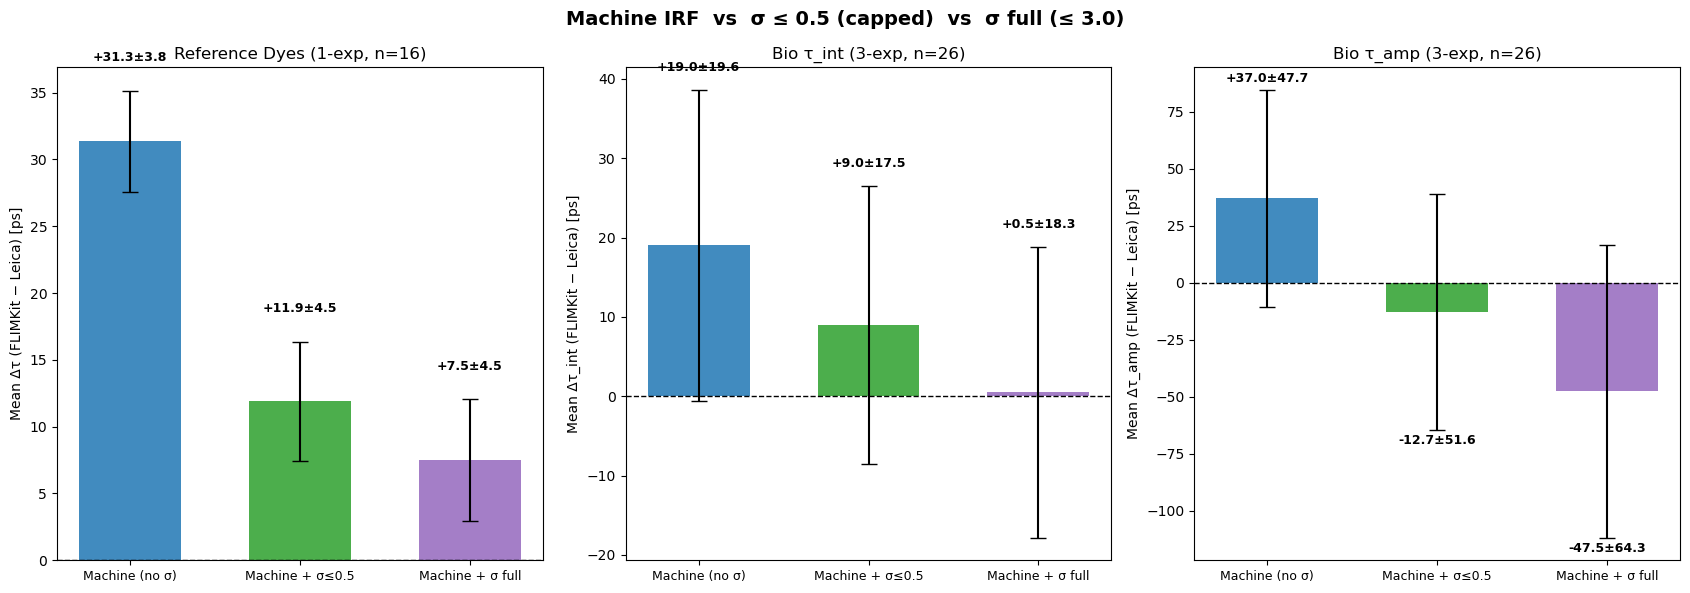

  Method                   Chems Δτ   Bio Δτ_int   Bio Δτ_amp
  ------------------------------------------------------------
  Machine (no σ)           +31.3±3.8      +19.0±19.6     +37.0±47.7
  Machine + σ≤0.5          +11.9±4.5       +9.0±17.5     -12.7±51.6
  Machine + σ full          +7.5±4.5       +0.5±18.3     -47.5±64.3

  Combined |Δ|:  no σ = 87.4 ps  |  σ≤0.5 = 33.6 ps  |  σ full = 55.5 ps


In [35]:
# ── Head-to-head: Machine IRF vs σ≤0.5 vs σ full (≤3.0) ─────────────────────

# -- Chems (1-exp): single τ --
chem_s05 = sweep_chem[0.5]
chem_methods = {
    "Machine (no σ)":  [r["base_dtau_ps"] for _, r in df_exp3.iterrows()],
    "Machine + σ≤0.5": [r["dtau_ps"] for r in chem_s05],
    "Machine + σ full": [r["sigma_dtau_ps"] for _, r in df_exp3.iterrows()],
}

# -- Bio (3-exp): τ_int and τ_amp --
bio_s05 = sweep_bio[0.5]
bio_methods_int = {
    "Machine (no σ)":  df_bio_sig["base_dtau_int_ps"].values,
    "Machine + σ≤0.5": np.array([r["dtau_int_ps"] for r in bio_s05]),
    "Machine + σ full": df_bio_sig["sig_dtau_int_ps"].values,
}
bio_methods_amp = {
    "Machine (no σ)":  df_bio_sig["base_dtau_amp_ps"].values,
    "Machine + σ≤0.5": np.array([r["dtau_amp_ps"] for r in bio_s05]),
    "Machine + σ full": df_bio_sig["sig_dtau_amp_ps"].values,
}

colors_3 = ["#1f77b4", "#2ca02c", "#9467bd"]
method_names = list(chem_methods.keys())

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# Panel 1: Chems Δτ
ax = axes[0]
x = np.arange(len(method_names))
vals = [np.mean(chem_methods[m]) for m in method_names]
errs = [np.std(chem_methods[m]) for m in method_names]
bars = ax.bar(x, vals, yerr=errs, capsize=6, color=colors_3, alpha=0.85, width=0.6)
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(method_names, fontsize=9)
ax.set_ylabel("Mean Δτ (FLIMKit − Leica) [ps]")
ax.set_title(f"Reference Dyes (1-exp, n={len(pairs)})")
for xi, m, s in zip(x, vals, errs):
    y_pos = m + s + 2 if m >= 0 else m - s - 2
    ax.text(xi, y_pos, f"{m:+.1f}±{s:.1f}", ha="center",
            va="bottom" if m >= 0 else "top", fontsize=9, fontweight="bold")

# Panel 2: Bio τ_int
ax = axes[1]
vals = [np.mean(bio_methods_int[m]) for m in method_names]
errs = [np.std(bio_methods_int[m]) for m in method_names]
bars = ax.bar(x, vals, yerr=errs, capsize=6, color=colors_3, alpha=0.85, width=0.6)
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(method_names, fontsize=9)
ax.set_ylabel("Mean Δτ_int (FLIMKit − Leica) [ps]")
ax.set_title(f"Bio τ_int (3-exp, n={len(lexar_pairs)})")
for xi, m, s in zip(x, vals, errs):
    y_pos = m + s + 2 if m >= 0 else m - s - 2
    ax.text(xi, y_pos, f"{m:+.1f}±{s:.1f}", ha="center",
            va="bottom" if m >= 0 else "top", fontsize=9, fontweight="bold")

# Panel 3: Bio τ_amp
ax = axes[2]
vals = [np.mean(bio_methods_amp[m]) for m in method_names]
errs = [np.std(bio_methods_amp[m]) for m in method_names]
bars = ax.bar(x, vals, yerr=errs, capsize=6, color=colors_3, alpha=0.85, width=0.6)
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(method_names, fontsize=9)
ax.set_ylabel("Mean Δτ_amp (FLIMKit − Leica) [ps]")
ax.set_title(f"Bio τ_amp (3-exp, n={len(lexar_pairs)})")
for xi, m, s in zip(x, vals, errs):
    y_pos = m + s + 2 if m >= 0 else m - s - 2
    ax.text(xi, y_pos, f"{m:+.1f}±{s:.1f}", ha="center",
            va="bottom" if m >= 0 else "top", fontsize=9, fontweight="bold")

plt.suptitle("Machine IRF  vs  σ ≤ 0.5 (capped)  vs  σ full (≤ 3.0)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary table
print("=" * 85)
print(f"  {'Method':<22} {'Chems Δτ':>10} {'Bio Δτ_int':>12} {'Bio Δτ_amp':>12}")
print(f"  {'-'*60}")
for m in method_names:
    c = np.mean(chem_methods[m])
    bi = np.mean(bio_methods_int[m])
    ba = np.mean(bio_methods_amp[m])
    cs = np.std(chem_methods[m])
    bis = np.std(bio_methods_int[m])
    bas = np.std(bio_methods_amp[m])
    print(f"  {m:<22} {c:>+7.1f}±{cs:<4.1f} {bi:>+9.1f}±{bis:<4.1f} {ba:>+9.1f}±{bas:<4.1f}")
total_no = abs(np.mean(chem_methods["Machine (no σ)"])) + abs(np.mean(bio_methods_int["Machine (no σ)"])) + abs(np.mean(bio_methods_amp["Machine (no σ)"]))
total_05 = abs(np.mean(chem_methods["Machine + σ≤0.5"])) + abs(np.mean(bio_methods_int["Machine + σ≤0.5"])) + abs(np.mean(bio_methods_amp["Machine + σ≤0.5"]))
total_full = abs(np.mean(chem_methods["Machine + σ full"])) + abs(np.mean(bio_methods_int["Machine + σ full"])) + abs(np.mean(bio_methods_amp["Machine + σ full"]))
print(f"\n  Combined |Δ|:  no σ = {total_no:.1f} ps  |  σ≤0.5 = {total_05:.1f} ps  |  σ full = {total_full:.1f} ps")

In [36]:
# ── Export all individual per-file data as CSV ────────────────────────────────
import os
out_dir = Path("csv_exports")
out_dir.mkdir(exist_ok=True)

# ── 1. Reference dyes (1-exp, 16 files) ──
# Merge: df_exp3 has machine/σ/σ+tail, df has machine/recon1/recon2, sweep_chem has σ≤0.5
chem_export = df_exp3[["name", "dye", "leica_tau",
                        "base_tau", "base_dtau_ps", "base_chi2",
                        "sigma_tau", "sigma_dtau_ps", "sigma_bins", "sigma_chi2"]].copy()
chem_export.rename(columns={
    "leica_tau": "leica_tau_ns",
    "base_tau": "machine_tau_ns", "base_dtau_ps": "machine_dtau_ps", "base_chi2": "machine_chi2",
    "sigma_tau": "machine_sigma_full_tau_ns", "sigma_dtau_ps": "machine_sigma_full_dtau_ps",
    "sigma_bins": "machine_sigma_full_sigma_bins", "sigma_chi2": "machine_sigma_full_chi2",
}, inplace=True)

# Add σ≤0.5 results
s05_chem = pd.DataFrame(sweep_chem[0.5])
chem_export["machine_sigma05_tau_ns"] = chem_export["leica_tau_ns"] + s05_chem["dtau_ps"].values / 1000
chem_export["machine_sigma05_dtau_ps"] = s05_chem["dtau_ps"].values
chem_export["machine_sigma05_sigma_bins"] = s05_chem["sigma"].values

# Add recon methods from df
chem_export["recon_bap1_tau_ns"] = df["recon1_tau"].values
chem_export["recon_bap1_dtau_ps"] = df["recon1_dtau_ps"].values
chem_export["recon_bap2_tau_ns"] = df["recon2_tau"].values
chem_export["recon_bap2_dtau_ps"] = df["recon2_dtau_ps"].values

chem_path = out_dir / "reference_dyes_1exp_all_methods.csv"
chem_export.to_csv(chem_path, index=False, float_format="%.4f")
print(f"Saved: {chem_path}  ({len(chem_export)} rows, {len(chem_export.columns)} cols)")
print(f"  Columns: {list(chem_export.columns)}")

# ── 2. Bio samples (3-exp, 26 files) ──
# Merge: df_bio_sig has machine/σ-full, df_lex has machine/recon1/recon2, 
#         df_exp4 has recon1/recon1+σ, sweep_bio has σ≤0.5
bio_export = df_bio_sig[["name", "n_exp",
                          "leica_tau_amp", "leica_tau_int",
                          "base_tau_amp", "base_tau_int",
                          "base_dtau_amp_ps", "base_dtau_int_ps", "base_chi2",
                          "sig_tau_amp", "sig_tau_int",
                          "sig_dtau_amp_ps", "sig_dtau_int_ps",
                          "sig_sigma", "sig_chi2"]].copy()
bio_export.rename(columns={
    "leica_tau_amp": "leica_tau_amp_ns", "leica_tau_int": "leica_tau_int_ns",
    "base_tau_amp": "machine_tau_amp_ns", "base_tau_int": "machine_tau_int_ns",
    "base_dtau_amp_ps": "machine_dtau_amp_ps", "base_dtau_int_ps": "machine_dtau_int_ps",
    "base_chi2": "machine_chi2",
    "sig_tau_amp": "machine_sigma_full_tau_amp_ns", "sig_tau_int": "machine_sigma_full_tau_int_ns",
    "sig_dtau_amp_ps": "machine_sigma_full_dtau_amp_ps", "sig_dtau_int_ps": "machine_sigma_full_dtau_int_ps",
    "sig_sigma": "machine_sigma_full_sigma_bins", "sig_chi2": "machine_sigma_full_chi2",
}, inplace=True)

# Add σ≤0.5 results
s05_bio = pd.DataFrame(sweep_bio[0.5])
bio_export["machine_sigma05_dtau_amp_ps"] = s05_bio["dtau_amp_ps"].values
bio_export["machine_sigma05_dtau_int_ps"] = s05_bio["dtau_int_ps"].values
bio_export["machine_sigma05_tau_amp_ns"] = bio_export["leica_tau_amp_ns"] + s05_bio["dtau_amp_ps"].values / 1000
bio_export["machine_sigma05_tau_int_ns"] = bio_export["leica_tau_int_ns"] + s05_bio["dtau_int_ps"].values / 1000
bio_export["machine_sigma05_sigma_bins"] = s05_bio["sigma"].values

# Add recon methods from df_lex
bio_export["recon_bap1_tau_amp_ns"] = df_lex["recon1_tau_amp"].values
bio_export["recon_bap1_tau_int_ns"] = df_lex["recon1_tau_int"].values
bio_export["recon_bap1_dtau_amp_ps"] = df_lex["recon1_dtau_amp_ps"].values
bio_export["recon_bap1_dtau_int_ps"] = df_lex["recon1_dtau_int_ps"].values

bio_path = out_dir / "bio_samples_3exp_all_methods.csv"
bio_export.to_csv(bio_path, index=False, float_format="%.4f")
print(f"\nSaved: {bio_path}  ({len(bio_export)} rows, {len(bio_export.columns)} cols)")
print(f"  Columns: {list(bio_export.columns)}")

# ── 3. σ_max sweep full detail ──
sweep_rows = []
for cap in sorted(sweep_chem.keys()):
    for r in sweep_chem[cap]:
        sweep_rows.append({"dataset": "chem", "sigma_max": cap,
                           "name": r["name"], "dye": r["dye"],
                           "dtau_ps": r["dtau_ps"], "sigma_fit": r["sigma"]})
    for r in sweep_bio[cap]:
        sweep_rows.append({"dataset": "bio", "sigma_max": cap,
                           "name": r["name"], "dye": "",
                           "dtau_amp_ps": r["dtau_amp_ps"], "dtau_int_ps": r["dtau_int_ps"],
                           "dtau_ps": None, "sigma_fit": r["sigma"]})
df_sweep = pd.DataFrame(sweep_rows)
sweep_path = out_dir / "sigma_max_sweep_all_files.csv"
df_sweep.to_csv(sweep_path, index=False, float_format="%.4f")
print(f"\nSaved: {sweep_path}  ({len(df_sweep)} rows)")

print(f"\n{'='*60}")
print(f"All CSVs exported to: {out_dir.resolve()}")

Saved: csv_exports/reference_dyes_1exp_all_methods.csv  (16 rows, 17 cols)
  Columns: ['name', 'dye', 'leica_tau_ns', 'machine_tau_ns', 'machine_dtau_ps', 'machine_chi2', 'machine_sigma_full_tau_ns', 'machine_sigma_full_dtau_ps', 'machine_sigma_full_sigma_bins', 'machine_sigma_full_chi2', 'machine_sigma05_tau_ns', 'machine_sigma05_dtau_ps', 'machine_sigma05_sigma_bins', 'recon_bap1_tau_ns', 'recon_bap1_dtau_ps', 'recon_bap2_tau_ns', 'recon_bap2_dtau_ps']

Saved: csv_exports/bio_samples_3exp_all_methods.csv  (26 rows, 24 cols)
  Columns: ['name', 'n_exp', 'leica_tau_amp_ns', 'leica_tau_int_ns', 'machine_tau_amp_ns', 'machine_tau_int_ns', 'machine_dtau_amp_ps', 'machine_dtau_int_ps', 'machine_chi2', 'machine_sigma_full_tau_amp_ns', 'machine_sigma_full_tau_int_ns', 'machine_sigma_full_dtau_amp_ps', 'machine_sigma_full_dtau_int_ps', 'machine_sigma_full_sigma_bins', 'machine_sigma_full_chi2', 'machine_sigma05_dtau_amp_ps', 'machine_sigma05_dtau_int_ps', 'machine_sigma05_tau_amp_ns', 'machin